# PUMS-LODES Data Preparation - for Calibration

## Core Issue

* PUMS tells us about work from home workers place of residence, but not place of work.
* LODES tells us about place of residence and place of work linkages but not the behavioral layer as to whether the job holder worked from home or telecommuted.
* Can we pick the behavioral signal from PUMS (that is, who tends to work from home) and the administrative job flow signal from lodes, and use the PUMS derived behavioral signal to enrich LODES releases?


## What we are doing
This notebook compares LODES and PUMS pre-pandemic OD matrices for the Bay Area. We break the OD into age/wage/industry strata and compare flows between the sources. We treat the OD ratios from the two sources as related via "K-factors" of sorts: they translate between measurement and conceptual differences.


## Data note
* **PUMS (Public Use Microdata Sample)**: Survey data capturing actual commute behavior, household characteristics, and demographic detail. Sample does *not* capture typical out of region residening teleworkers who may have a work relationship with the Bay Area (e.g. residing in Sacramento or Stockton).
  * When subtracting out work from home, PUMS represents a **person-based** measure of flows
* **LODES (LEHD Origin-Destination Employment Statistics)**: Tabulation of administrative records of jobs from unemployment insurance, similar to data behind QCEW. Provides nearly complete employment counts at census block level resolution, but lacks both deep industry, wage, and age resolution, let alone behavioral detail on whether a person actually makes the trip on a work day and has other known issues (multiple job holders, imputed workplace locations for some records).
  * LEHD LODES represents administrative relationships which may or may not translate to travel on any given day. The LEHD / LODES data is organized around a job, not necessarily a person. We know that some persons hold more than one job.

We can interpret the PUMS data as a behavioral slice, while the LODES data represents an administrative slice. An OD cell with identical flows would suggest parity between the slices. A much larger LODES cell might suggest:
* a headquarter overcounting problem - more jobs in a locality due to merely accounting issues, or
* the presence of a larger than average work from home share in the PUMS data - in which case we won't observe the actual job site due to a Census Bureau recoding practice enforcing POWPUMAs reflect the home address of the survey respondnent. This is an increasingly serious issue for the PUMS sample insofar as it severly limits the place of work utility of this data source.

Separately, there may be just be statistical noise due to sampling or non-sampling errors, or errors related to precision in measurement. Take, for example, industry coding: An establishment in the LODES data may be engaged in multiple economic activities, but the respondent for the administrative data need to select one. A computer company, for example, may offer both services and hardware. Invariably, the selection of the specific NAICS code will tend to vary between the administrative data and the survey based data, relying on the respondent to provide a textual description of the industry in which their company focuses their work.


## Goal: Find a way to use LODES, without the large scale noise due to WFH place of work recoding

The obtained **K-factors** (calibration factors) relate PUMS-based commute behavior to match LODES administrative totals within limited / select demographic strata. Since we subset the PUMS data to labor force, we capture the "mobile" / non-WFH population with this slice, though it could be expanded to do the inverse: obtain from a LODES data release the share of commuters / non-commuters. 
The approach seeks to:
- Preserve behavioral realism from PUMS (who commutes where, by demographics)
- Anchor to administrative totals from LODES (preventing systematic over/under-prediction)
- Offer detail by age, earnings, and industry to capture heterogeneity of travel patterns

## Geographic Alignment

To relate the two datasets spatially we need to crosswalk:
* **LODES (V8, from 2025)** uses 2020 Census blocks
* **PUMS** uses two separate levels of geographic detail:
  * For residential (that is, most) tabulations, the geography PUMAs (Public Use Microdata Areas) which vary by vintage.
    * 2012-2021 data: 2012 PUMAs (2010-based geography vintage)
    * 2022+ data: 2022 PUMAs (2020-based geography vintage)
  * For place of work data, PUMS offers the POWPUMA variable, which is more aggregate than the residence based PUMAs. While there are 281 PUMAs in California, there are only 40 POWPUMAs in the state. For larger counties, POWPUMAs are conterminous. For smaller counties, they will be aggregated together to the same larger POWPUMA. For reference, California has 58 counties.


## Workflow

1. **Load PUMS**: We read person-level PUMS data, filter to employed residents, create demographic categories (age/earnings/industry) to match LODES strata
2. **Load LODES**: Read block-level OD flows, use vintage-appropriate crosswalk (simple point-in-poly) to assign block to PUMAs, and then aggregate to PUMA to County. 
3. **Stratify**: Create cross-tabulated flows by residence PUMA x workplace County x age x earnings x industry. While PUMS can be cross-classified into workers by age, wage, industry bins (3 each, for a total of 9 cells), with LODES, we get three independent distributions - total jobs by age group; total jobs by wage group; total jobs by industry group. We create a naive even-share cross-categorization, similar to the seed distribution one would use for further IPF processing. 
4. **Calculate K-factors**: For each stratum and geographic cell (we go for counties, and vicinity or halo counties), we then compute K = PUMS_commuters / LODES_jobs

## Outputs

- **PUMS OD**: Residence PUMA -> Workplace County flows with person weights, stratified by demographics
- **LODES OD**: Residence PUMA -> Workplace County flows with job counts, stratified by demographics  
- **Calibration Matrix**: K-factors by stratum for use in downstream travel models

The resulting K-factors can be applied to scale future LODES-based commute shares to be more akin to PUMS "behavioral" worker job totals. 

*Note the limitations - that the K-factors will likely overstate actual commuters based on post-COVID LODES data since the "training" was on pre-COVID data.*

## Contents

- [Setup](#setup)
- [1. PUMS Data Preparation](#1-pums-data-preparation)
- [2. LODES Data Preparation](#2-lodes-data-preparation)
- [3. Build Calibration Matrix](#3-build-calibration-matrix)
  - [The K-Factors](#the-k-factors)
  - [Summary Statistics](#summary-statistics)
  - [Bay Area County-Level Flow Comparison](#bay-area-county-level-flow-comparison)
  - [What PUMS and LODES Are Each Telling Us](#what-pums-and-lodes-are-each-telling-us)
- [4. WFH Adjustment to K-Factors](#4-wfh-adjustment-to-k-factors)
  - [Motivation](#motivation)
  - [Approach](#approach)
  - [Identifying Assumptions](#identifying-assumptions)
  - [Upshot: Reading the Mobility Retention Factor](#upshot-reading-the-mobility-retention-factor)
- [5. Out-of-Sample Application: 2023 LODES](#5-out-of-sample-application-2023-lodes-with-wfh-adjusted-k-factors)
  - [Reading the Three Heatmaps](#reading-the-three-heatmaps)


In [1]:
import pandas as pd
import numpy as np
import pathlib
import os
from types import SimpleNamespace

import seaborn as sns
import matplotlib.pyplot as plt

# ── Path setup ────────────────────────────────────────────────────
M_DRIVE       = pathlib.Path('/Volumes/Data/Models') if os.name == 'posix' else pathlib.Path('M:/')
LODES_PATH    = M_DRIVE / 'Data/Census/LEHD/RAW/lodes'
PUMS_PATH     = M_DRIVE / 'Data/Census/PUMS'
CROSSWALK_PATH = M_DRIVE / 'Crosswalks/geo/block-to-puma'
OUT_PATH      = M_DRIVE / 'Projects/Worker Flows/pums_to_lodes_reconciliation'
OUT_PATH.mkdir(parents=True, exist_ok=True)

# Analysis year 
YEAR = 2019

# ── Display defaults ──────────────────────────────────────────────
pd.options.display.float_format = '{:,.0f}'.format
pct = lambda x: x / x.sum()   # convenience: column-wise percentage share

# ── Vintage configuration ─────────────────────────────────────────
# PUMS 2012-2021: 2010-based PUMAs (vintage label '2019')
# PUMS 2022+    : 2020-based PUMAs (vintage label '2024')

# maping of input year to relevant vintage
_VINTAGE_RANGES = [
    (2012, 2021, '2019'),
    (2022, 9999, '2024'),
]
_PUMA_LABEL    = {'2019': 'puma19',         '2024': 'puma24'}
_POWPUMA_LABEL = {'2019': 'POWSTPUMA_2019', '2024': 'POWSTPUMA_2024'}


def get_vintage_config(year):
    """Return a SimpleNamespace of all vintage-dependent labels/filenames."""
    for lo, hi, vintage in _VINTAGE_RANGES:
        if lo <= year <= hi:
            puma  = _PUMA_LABEL[vintage]
            ppuma = _POWPUMA_LABEL[vintage]
            return SimpleNamespace(
                year                   = year,
                vintage                = vintage,
                puma_label             = puma,
                powpuma_label          = ppuma,
                block_puma_file        = f'blocks2020_x_puma{vintage}_xw.csv',
                block_powpuma_file     = f'blocks2020_x_powpuma{vintage}_xw.csv',
                puma_to_county_file    = f'stpuma_to_county_{vintage}.csv',
                powpuma_to_county_file = f'powstpuma_to_county_{vintage}.csv',
            )
    raise ValueError(f"No PUMA vintage config found for year {year}")


vc = get_vintage_config(YEAR)

# Uppercase aliases kept for backward compatibility with downstream cells
PUMA_VINTAGE              = vc.vintage
PUMA_LABEL                = vc.puma_label
POWPUMA_LABEL             = vc.powpuma_label
BLOCK_PUMA_XWALK_FILE     = vc.block_puma_file
BLOCK_POWPUMA_XWALK_FILE  = vc.block_powpuma_file
PUMA_TO_COUNTY_XWALK_FILE = vc.puma_to_county_file
POWPUMA_TO_COUNTY_XWALK_FILE = vc.powpuma_to_county_file

print(f"Analysis year:              {YEAR}")
print(f"PUMA vintage:               {PUMA_VINTAGE}  ({PUMA_LABEL})")
print(f"Block -> PUMA crosswalk:     {BLOCK_PUMA_XWALK_FILE}")
print(f"PUMA -> county crosswalk:    {PUMA_TO_COUNTY_XWALK_FILE}")
print(f"POWPUMA -> county crosswalk: {POWPUMA_TO_COUNTY_XWALK_FILE}")
print(f"LODES block vintage:        2020 (LODES V8)")


Analysis year:              2019
PUMA vintage:               2019  (puma19)
Block -> PUMA crosswalk:     blocks2020_x_puma2019_xw.csv
PUMA -> county crosswalk:    stpuma_to_county_2019.csv
POWPUMA -> county crosswalk: powstpuma_to_county_2019.csv
LODES block vintage:        2020 (LODES V8)


In [2]:

# PUMS Pipeline Helper Functions

PUMS_KEEP_COLS = [
    'SERIALNO', 'PUMA', 'POWPUMA', 'POWSP', 'STATE', 'JWTR',
    'AGEP', 'WAGP', 'NAICSP', 'ESR', 'PWGTP'
]

COLUMN_ALIASES = {
    'STATE':   ['ST', 'STATE'],
    'PUMA':    ['PUMA', 'PUMA00', 'PUMA10'],
    'JWTR':    ['JWTR', 'JWTRNS'],
    'POWPUMA': ['POWPUMA', 'POWPUMA00', 'POWPUMA10'],
}


def resolve_column_names(file_path, desired_cols, aliases=None):
    """Map desired standard column names to the actual names present in a PUMS file."""
    if aliases is None:
        aliases = COLUMN_ALIASES
    header_upper = {c.upper(): c for c in pd.read_csv(file_path, nrows=0).columns}
    col_map = {}
    for desired in desired_cols:
        du = desired.upper()
        if du in header_upper:
            col_map[desired] = header_upper[du]
        elif du in aliases:
            for alias in aliases[du]:
                if alias in header_upper:
                    col_map[desired] = header_upper[alias]
                    break
    return col_map


def load_pums_raw(year, pums_path=PUMS_PATH, keep_cols=None):
    """
    Load and concatenate PUMS person files for *year*.
    Returns a raw, string-typed DataFrame (numeric coercion done downstream).
    Works for any national PUMS vintage (psam_pus*.csv or ss{yy}pus*.csv).
    """
    if keep_cols is None:
        keep_cols = PUMS_KEEP_COLS
    year_path = pums_path / f'PUMS {year}'
    if not year_path.exists():
        year_path = pums_path / str(year)
    files = (sorted(year_path.glob('psam_pus*.csv'))
             + sorted(year_path.glob(f'ss{str(year)[-2:]}pus*.csv')))
    if not files:
        raise FileNotFoundError(f"No PUMS files found in {year_path}")
    parts = []
    for f in files:
        cmap = resolve_column_names(f, keep_cols)
        if not cmap:
            continue
        print(f"  {f.name}")
        chunk = pd.read_csv(f, usecols=list(cmap.values()),
                            dtype={v: str for v in cmap.values()})
        chunk = chunk.rename(columns={v: k for k, v in cmap.items()})
        parts.append(chunk)
    if not parts:
        raise ValueError(f"No recognised columns in PUMS files for {year}")
    df = pd.concat(parts, ignore_index=True)
    print(f"  -> {len(df):,} records loaded ({year})")
    return df


def categorize_industry(naics_code):
    """Map a NAICS string to a LODES industry stratum (SI01 / SI02 / SI03)."""
    if pd.isna(naics_code) or naics_code == '':
        return 'SI03'
    n2 = str(naics_code)[:2]
    if n2 in {'11', '21', '23', '31', '32', '33'}:
        return 'SI01'   # Goods Producing
    if n2 in {'22', '42', '44', '45', '48', '49'}:
        return 'SI02'   # Trade / Transport / Utilities
    return 'SI03'       # All Other Services


def add_lodes_strata(df):
    """
    Add age_cat (SA01/02/03), wage_cat (SE01/02/03), indp_cat (SI01/02/03).
    Modifies df in-place; also returns df for chaining.
    """
    df['age_cat']  = pd.cut(df['AGEP'].astype(float),
                            bins=[0, 29, 54, 120], labels=['SA01', 'SA02', 'SA03'])
    df['wage_cat'] = pd.cut(df['WAGP'].astype(float) / 12,
                            bins=[0, 1250, 3333, np.inf], labels=['SE01', 'SE02', 'SE03'])
    df['indp_cat'] = df['NAICSP'].apply(categorize_industry)
    return df


def prepare_pums_commuters(pums_raw, puma_xwalk, powpuma_xwalk, bay_area_fips):
    """
    Full preparation pipeline: raw PUMS -> commuter-filtered df with geo flags and strata.

    Filters:  ESR in {1,2,4,5} (employed) AND JWTR != 11 (excludes work-from-home).
    Adds:     STPUMA, POWSTPUMA, h_*/w_* county/region flags, age_cat/wage_cat/indp_cat.

    Parameters
    ----------
    puma_xwalk    : DataFrame indexed on STPUMA  (residence geography)
    powpuma_xwalk : DataFrame indexed on POWSTPUMA (workplace geography)
    bay_area_fips : dict or set of 5-digit FIPS strings
    """
    df = pums_raw.copy()
    for col in ('AGEP', 'WAGP', 'PWGTP', 'ESR', 'JWTR'):
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df['ESR'].isin([1, 2, 4, 5])
            & df['JWTR'].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12])].copy()

    # Geographic composite codes
    df['STPUMA']    = df['STATE'].str.zfill(2) + df['PUMA'].str.zfill(5)
    df['POWSTPUMA'] = df['POWSP'].str.zfill(3) + df['POWPUMA'].str.zfill(5)

    # Residence geography
    df['STCOUNTY']     = df['STPUMA'].map(puma_xwalk.fips)
    df['h_counties']   = df['STPUMA'].map(puma_xwalk.counties)
    df['h_cog_region'] = df['STPUMA'].map(puma_xwalk.ca_cog_region).astype('category')
    df['h_bayarea']    = df['STCOUNTY'].isin(bay_area_fips)
    df['h_ca']         = df['STCOUNTY'].str.slice(0, 2) == '06'

    # Workplace geography
    df['POWSTCOUNTY']  = df['POWSTPUMA'].map(powpuma_xwalk.fips)
    df['w_counties']   = df['POWSTPUMA'].map(powpuma_xwalk.counties)
    df['w_cog_region'] = df['POWSTPUMA'].map(powpuma_xwalk.ca_cog_region).astype('category')
    df['w_bayarea']    = df['POWSTCOUNTY'].isin(bay_area_fips)
    df['w_ca']         = df['POWSTCOUNTY'].str.slice(0, 2) == '06'

    add_lodes_strata(df)

    n = len(df)
    print(f"  Commuters (non-WFH): {n:,} records  |  weighted: {df['PWGTP'].sum():,.0f}")
    print(f"  Residence PUMA mapped: {df['STCOUNTY'].notna().sum():,}/{n:,} "
          f"({100*df['STCOUNTY'].notna().mean():.1f}%)")
    print(f"  Workplace PUMA mapped: {df['POWSTCOUNTY'].notna().sum():,}/{n:,} "
          f"({100*df['POWSTCOUNTY'].notna().mean():.1f}%)")
    return df


def build_pums_od(pums_workers):
    """
    Aggregate commuter-level pums_workers to PUMA x POWPUMA x strata OD flows.
    Restricts to (h_bayarea | w_bayarea) & (h_ca & w_ca).
    Returns pums_od DataFrame.
    """
    od = (
        pums_workers.query('(h_bayarea | w_bayarea) & (w_ca & h_ca)')
        .groupby(['STPUMA', 'POWSTPUMA', 'h_counties', 'w_counties',
                  'age_cat', 'wage_cat', 'indp_cat'],
                 observed=True, dropna=False)
        ['PWGTP'].sum()
        .reset_index()
        .rename(columns={
            'STPUMA': 'res_puma', 'POWSTPUMA': 'w_powpuma',
            'PWGTP': 'pums_commuters'
        })
    )
    print(f"  PUMS OD: {len(od):,} rows  |  total weighted flows: {od['pums_commuters'].sum():,.0f}")
    return od


def compute_wfh_shares(pums_raw_or_year, puma_xwalk, bay_area_fips,
                       year_label=None, pums_path=PUMS_PATH):
    """
    Compute WFH share by age/wage/industry strata for Bay Area employed residents.
    Includes WFH workers in both numerator and denominator (unlike prepare_pums_commuters).

    Parameters
    ----------
    pums_raw_or_year : DataFrame or int
        Already-loaded raw PUMS df, or an integer year (will call load_pums_raw).
    puma_xwalk       : DataFrame indexed on STPUMA with a 'fips' column.
    bay_area_fips    : dict or set of 5-digit FIPS strings.
    year_label       : str or int, optional
        If provided, numeric result columns are suffixed _{year_label}.

    Returns
    -------
    DataFrame with columns:
        age_cat, wage_cat, indp_cat,
        total_employed[_{label}], wfh_workers[_{label}], wfh_share[_{label}]
    """
    keep = ['SERIALNO', 'PUMA', 'STATE', 'JWTR', 'AGEP', 'WAGP', 'NAICSP', 'ESR', 'PWGTP']
    if isinstance(pums_raw_or_year, int):
        pums_raw_or_year = load_pums_raw(pums_raw_or_year, pums_path=pums_path, keep_cols=keep)
    df = pums_raw_or_year.copy()
    for col in ('AGEP', 'WAGP', 'PWGTP', 'ESR', 'JWTR'):
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df['ESR'].isin([1, 2, 4, 5])].copy()
    df['STPUMA']   = df['STATE'].str.zfill(2) + df['PUMA'].str.zfill(5)
    df['STCOUNTY'] = df['STPUMA'].map(puma_xwalk.fips)
    df = df[df['STCOUNTY'].isin(bay_area_fips)].copy()
    df['is_wfh'] = df['JWTR'] == 11
    add_lodes_strata(df)

    result = (
        df.groupby(['age_cat', 'wage_cat', 'indp_cat'], observed=True)
        .apply(lambda g: pd.Series({
            'total_employed': g['PWGTP'].sum(),
            'wfh_workers':    g.loc[g['is_wfh'], 'PWGTP'].sum(),
        }), include_groups=False)
        .reset_index()
    )
    result['wfh_share'] = result['wfh_workers'] / result['total_employed']
    if year_label is not None:
        lbl = year_label
        result = result.rename(columns={
            'total_employed': f'total_employed_{lbl}',
            'wfh_workers':    f'wfh_workers_{lbl}',
            'wfh_share':      f'wfh_share_{lbl}',
        })
    tot = result.filter(like='total_employed').values.sum()
    wfh = result.filter(like='wfh_workers').values.sum()
    print(f"  Bay Area employed: {tot:,.0f}  |  WFH: {wfh:,.0f} ({wfh/tot:.1%})")
    return result


print("PUMS helper functions defined.")


PUMS helper functions defined.


In [3]:

# Crosswalk Loader  +  LODES Pipeline Helper Functions
# (get_vintage_config() and its lookup tables are defined in the setup cell above)


# Crosswalk loader


def load_crosswalks(year_or_vc, crosswalk_path, cog_regions):
    """
    Load and enrich all geographic crosswalks for a given PUMS year.

    Handles vintage selection automatically.  Returns a SimpleNamespace with:
      .puma     - PUMA   -> county  (indexed on STPUMA,    with ca_cog_region column)
      .powpuma  - POWPUMA -> county  (indexed on POWSTPUMA, with ca_cog_region column)
      .block    - block20_id -> PUMA / POWPUMA  (indexed on block20_id)
      .vc       - the vintage config SimpleNamespace

    Parameters
    ----------
    year_or_vc    : int  or  SimpleNamespace from get_vintage_config()
    crosswalk_path: pathlib.Path or str - directory containing the crosswalk CSVs
    cog_regions   : dict  {fips5 -> region_label}
    """
    vc_local = (year_or_vc if isinstance(year_or_vc, SimpleNamespace)
                else get_vintage_config(year_or_vc))
    p = pathlib.Path(crosswalk_path)

    def _add_cog(xwalk, cog_col='ca_cog_region', fips_col='fips'):
        """
        Map each PUMA/POWPUMA row to its COG region(s).
        The 'fips' column may contain a comma-separated list if the PUMA spans
        multiple counties; those counties may fall in different COGs.
        """
        xwalk[cog_col] = (
            xwalk[fips_col].str.split(', ')
            .explode()
            .map(cog_regions)
            .fillna('Outside CA Cogs')
            .groupby(level=0)
            .apply(lambda x: '; '.join(sorted(set(x))))
        )
        return xwalk

    # PUMA -> county
    puma_xwalk = (pd.read_csv(p / vc_local.puma_to_county_file, dtype=str)
                    .set_index('STPUMA'))
    puma_xwalk = _add_cog(puma_xwalk)

    # POWPUMA -> county
    powpuma_xwalk = (pd.read_csv(p / vc_local.powpuma_to_county_file, dtype=str)
                       .set_index('POWSTPUMA'))
    powpuma_xwalk = _add_cog(powpuma_xwalk)

    # block -> PUMA + POWPUMA
    puma_col   = vc_local.puma_label + '_id'
    bl_puma    = pd.read_csv(p / vc_local.block_puma_file,
                             dtype={'block20_id': str, puma_col: str})
    bl_powpuma = pd.read_csv(p / vc_local.block_powpuma_file,
                              dtype={'block20_id': str, vc_local.powpuma_label: str})
    block_xwalks = (
        pd.merge(bl_powpuma, bl_puma, on='block20_id', validate='1:1')
        .set_index('block20_id')
    )

    print(f"Crosswalks loaded  (vintage {vc_local.vintage})")
    print(f"  PUMA -> county:          {len(puma_xwalk):,} rows")
    print(f"  POWPUMA -> county:       {len(powpuma_xwalk):,} rows")
    print(f"  block -> PUMA/POWPUMA:   {len(block_xwalks):,} blocks")
    print(f"  block columns: {list(block_xwalks.columns)}")

    return SimpleNamespace(
        puma    = puma_xwalk,
        powpuma = powpuma_xwalk,
        block   = block_xwalks,
        vc      = vc_local,
    )



# LODES column groupings


LODES_AGE_COLS  = ['SA01', 'SA02', 'SA03']
LODES_WAGE_COLS = ['SE01', 'SE02', 'SE03']
LODES_INDP_COLS = ['SI01', 'SI02', 'SI03']
LODES_DEMO_COLS = LODES_AGE_COLS + LODES_WAGE_COLS + LODES_INDP_COLS


# LODES pipeline functions


def _coerce_geocode(series, width=15, col_name='geocode'):
    """Normalize a geocode Series to zero-padded strings of *width* digits."""
    s = series.astype('string').str.strip()
    float_mask = s.notna() & s.str.fullmatch(r'\d+\.0')
    if float_mask.any():
        s.loc[float_mask] = s.loc[float_mask].str[:-2]
    invalid = s.notna() & ~s.str.fullmatch(r'\d+')
    if invalid.any():
        raise ValueError(
            f"{col_name}: unexpected non-digit values: "
            f"{s.loc[invalid].dropna().head(5).tolist()}"
        )
    return s.str.zfill(width)


def _read_lodes_file(path, geocode_cols=('h_geocode', 'w_geocode')):
    """Read one LODES CSV/gz with geocode normalisation."""
    width     = 15
    dtype_map = {c: 'string' for c in geocode_cols}
    try:
        df = pd.read_csv(path, engine='pyarrow', dtype=dtype_map)
    except Exception:
        df = pd.read_csv(path, engine='c', dtype=dtype_map)
    for col in geocode_cols:
        if col in df.columns:
            s = df[col].astype('string')
            needs_fix = (s.notna() & ((s.str.len() != width) | (~s.str.fullmatch(r'\d+')))).any()
            df[col] = _coerce_geocode(s, width=width, col_name=col) if needs_fix else s
    return df


def load_lodes_od(state, year, job_type='JT00', lodes_path=None):
    """
    Load and concatenate LODES main + aux OD files for a given state and year.

    LODES V8 uses 2020-vintage census blocks regardless of the data year.

    Parameters
    ----------
    state     : str   two-letter state abbreviation, e.g. 'ca'
    year      : int
    job_type  : str   LODES job-type code (default 'JT00' = all jobs)
    lodes_path: path  directory containing the LODES gz files;
                      defaults to the module-level LODES_PATH variable
    """
    lp = pathlib.Path(lodes_path or LODES_PATH)
    dfs = []
    for kind in ('main', 'aux'):
        fname = f'{state}_od_{kind}_{job_type}_{year}.csv.gz'
        fpath = lp / fname
        if not fpath.exists():
            raise FileNotFoundError(f"LODES file not found: {fpath}")
        print(f"  Loading {fname}…")
        dfs.append(_read_lodes_file(fpath))
    od = pd.concat(dfs, ignore_index=True)
    print(f"  -> {len(od):,} records  |  S000={od['S000'].sum():,.0f}")
    return od


def tag_lodes_geography(lodes_od, xwalks, bay_area_fips, cog_regions):
    """
    Attach PUMA, POWPUMA, county flags, and region labels to a LODES OD DataFrame.

    Parameters
    ----------
    xwalks        : SimpleNamespace from load_crosswalks()
    bay_area_fips : collection of 5-digit county FIPS strings
    cog_regions   : dict  {fips5 -> region_label}

    Returns a copy of the input DataFrame with additional geographic columns.

    County grouping columns (h_counties / w_counties) use the ACS-based PUMA/POWPUMA
    county labels (res_counties / pow_counties in the block crosswalk), which may
    aggregate small counties - matching the groupings in the PUMS data.
    """
    vcl = xwalks.vc
    blk = xwalks.block
    df  = lodes_od.copy()

    puma_col = vcl.puma_label + '_id'      # e.g. 'puma19_id'

    # Derive embedded county from block FIPS (first 5 digits)
    h_cty = df.h_geocode.str[:5]
    w_cty = df.w_geocode.str[:5]

    # Residence geography
    df['h_puma']       = df.h_geocode.map(blk[puma_col])
    df['h_county']     = h_cty
    # Use ACS PUMA-based county grouping (res_counties); fall back for older crosswalk files
    df['h_counties']   = df.h_geocode.map(blk['res_counties'])
    df['h_bayarea']    = h_cty.isin(bay_area_fips)
    df['h_cog_region'] = h_cty.map(cog_regions).fillna('Outside CA Cogs')
    df['h_ca']         = df.h_geocode.str[:2] == '06'

    # Workplace geography
    df['w_powpuma']    = df.w_geocode.map(blk[vcl.powpuma_label])
    df['w_county']     = w_cty
    # Use ACS POWPUMA-based county grouping (pow_counties); fall back for older crosswalk files
    
    df['w_counties']   = df.w_geocode.map(blk['pow_counties'])
    df['w_bayarea']    = w_cty.isin(bay_area_fips)
    df['w_cog_region'] = w_cty.map(cog_regions).fillna('Outside CA Cogs')
    df['w_ca']         = df.w_geocode.str[:2] == '06'

    # Vintage-labelled aliases (backward compatibility with downstream cells)
    df[vcl.powpuma_label] = df['w_powpuma']
    df[vcl.puma_label]    = df['h_puma']

    n = len(df)
    print(f"  h_puma matched:    {df['h_puma'].notna().sum():,}/{n:,}  "
          f"({100 * df['h_puma'].notna().mean():.1f} %)")
    print(f"  w_powpuma matched: {df['w_powpuma'].notna().sum():,}/{n:,}  "
          f"({100 * df['w_powpuma'].notna().mean():.1f} %)")
    return df


def aggregate_lodes_to_puma(lodes_od, bay_area_fips):
    """
    Filter to CA flows touching the Bay Area and aggregate to
    h_puma x h_counties x w_powpuma x w_counties.

    Retains marginal age / wage / industry totals and appends 'total_jobs'.
    """
    agg = (
        lodes_od.query('(h_bayarea | w_bayarea) & (h_ca & w_ca)')
        .groupby(['h_puma', 'h_counties', 'w_powpuma', 'w_counties'], as_index=False)
        [LODES_DEMO_COLS].sum()
    )
    agg['total_jobs'] = agg[LODES_AGE_COLS].sum(axis=1)
    print(f"  Aggregated: {len(agg):,} PUMA-county pairs  |  "
          f"total jobs: {agg['total_jobs'].sum():,.0f}")
    return agg


def stratify_lodes_od(lodes_agg):
    """
    Cross-stratify LODES marginals into age x wage x industry cells using
    the statistical-independence assumption (seed for zero-iteration IPF).

    Returns lodes_od_strata with columns:
        res_puma, h_counties, w_powpuma, w_counties,
        age_cat, wage_cat, indp_cat, lodes_jobs
    """
    id_cols = ['h_puma', 'h_counties', 'w_powpuma', 'w_counties', 'total_jobs']

    def _proportions(df, cols, cat_name):
        m = df.melt(id_vars=id_cols, value_vars=cols,
                    var_name=cat_name, value_name='count')
        m[f'{cat_name}_prop'] = (m['count'] / m['total_jobs']).fillna(0)
        return m.drop(columns='count')

    merge_keys = ['h_puma', 'h_counties', 'w_powpuma', 'w_counties', 'total_jobs']
    strata = pd.merge(
        _proportions(lodes_agg, LODES_AGE_COLS,  'age_cat'),
        _proportions(lodes_agg, LODES_WAGE_COLS, 'wage_cat'),
        on=merge_keys,
    )
    strata = pd.merge(
        strata,
        _proportions(lodes_agg, LODES_INDP_COLS, 'indp_cat'),
        on=merge_keys,
    )
    strata['lodes_jobs'] = (
        strata['total_jobs']
        * strata['age_cat_prop']
        * strata['wage_cat_prop']
        * strata['indp_cat_prop']
    )
    strata = (
        strata[strata['lodes_jobs'] > 0]
        .rename(columns={'h_puma': 'res_puma'})
        [['res_puma', 'h_counties', 'w_powpuma', 'w_counties',
          'age_cat', 'wage_cat', 'indp_cat', 'lodes_jobs']]
        .reset_index(drop=True)
    )

    check    = strata.loc[strata['wage_cat'] == 'SE01', 'lodes_jobs'].sum()
    original = lodes_agg['SE01'].sum()
    rel_diff = abs(check - original) / original if original else float('nan')
    print(f"  Reconstruction check SE01: {check:,.0f} vs original {original:,.0f}  "
          f"(rel. diff {rel_diff:.2e})")
    print(f"  Stratified OD: {len(strata):,} rows  |  "
          f"total jobs: {strata['lodes_jobs'].sum():,.0f}")
    return strata


print("LODES + crosswalk helper functions defined.")


LODES + crosswalk helper functions defined.


In [4]:
# Define Bay Area counties in display order

bay_area_counties = {
    '06001': 'Alameda',
    '06013': 'Contra Costa',
    '06041': 'Marin',
    '06055': 'Napa',
    '06075': 'San Francisco',
    '06081': 'San Mateo',
    '06085': 'Santa Clara',
    '06095': 'Solano',
    '06097': 'Sonoma'
}

halofips = {
    '06077': 'San Joaquin',
    '06099': 'Stanislaus',
    '06067': 'Sacramento',
    #'06047': 'Merced',
    #'06113': 'Yolo',
    #'06115': 'Yuba, Sutter',
    #'06101': 'Yuba, Sutter',
    #'06017': 'El Dorado',
    #'06061': 'Placer',
    '06087': 'Santa Cruz',
    '06069': 'Monterey, San Benito',
    '06053': 'Monterey, San Benito',
    #'06033': 'Mendocino, Lake',
    #'06045': 'Mendocino, Lake',
}
county_list = list(bay_area_counties.values())

# Create reverse lookup (county name to FIPS)
county_fips = {v: k for k, v in bay_area_counties.items()}

cog_regions = {
    # ABAG/MTC
    '06001': 'ABAG/MTC',   # Alameda
    '06013': 'ABAG/MTC',   # Contra Costa
    '06041': 'ABAG/MTC',   # Marin
    '06055': 'ABAG/MTC',   # Napa
    '06075': 'ABAG/MTC',   # San Francisco
    '06081': 'ABAG/MTC',   # San Mateo
    '06085': 'ABAG/MTC',   # Santa Clara
    '06095': 'ABAG/MTC',   # Solano
    '06097': 'ABAG/MTC',   # Sonoma
    # SACOG
    '06017': 'SACOG',      # El Dorado
    '06061': 'SACOG',      # Placer
    '06067': 'SACOG',      # Sacramento
    '06101': 'SACOG',      # Sutter
    '06113': 'SACOG',      # Yolo
    '06115': 'SACOG',      # Yuba
    # SCAG
    '06025': 'SCAG',       # Imperial
    '06037': 'SCAG',       # Los Angeles
    '06059': 'SCAG',       # Orange
    '06065': 'SCAG',       # Riverside
    '06071': 'SCAG',       # San Bernardino
    '06111': 'SCAG',       # Ventura
    # Other COGs
    '06047': 'MCAG',       # Merced
    '06053': 'AMBAG',      # Monterey
    '06069': 'AMBAG',      # San Benito
    '06087': 'AMBAG',      # Santa Cruz
    '06077': 'SJCOG',      # San Joaquin
    '06099': 'STANCOG',    # Stanislaus
    '06073': 'SANDAG',     # San Diego    
    # Other
    '06033': 'Rest of CA', # Lake
    '06045': 'Mendocino CAG',
}

halo_list = list(set(halofips.values()))
county_combo_list = county_list + halo_list


## Setup


In [5]:
# Load pre-made block-to-puma crosswalk and block to powpuma crosswalk

ca_fips_path = M_DRIVE / 'Crosswalks/geo/st06_ca_cou2020.txt'
ca_county_fips = pd.read_csv(ca_fips_path,sep='|',dtype=str)
ca_county_fips['STCOUNTY'] = ca_county_fips.STATEFP + ca_county_fips.COUNTYFP
ca_county_fips['county_name'] = ca_county_fips.COUNTYNAME.str.replace(' County','')
ca_county_fips_map= ca_county_fips.set_index('STCOUNTY').county_name


In [6]:
# Load all crosswalks (PUMA->county, POWPUMA->county, block->PUMA/POWPUMA)
# Vintage (2019 vs 2024 PUMAs) is resolved automatically from YEAR.
xwalks = load_crosswalks(YEAR, CROSSWALK_PATH, cog_regions)

# Unpack into named variables for backward compatibility with downstream cells
puma_county_xwalk    = xwalks.puma
powpuma_county_xwalk = xwalks.powpuma
block_xwalks         = xwalks.block


Crosswalks loaded  (vintage 2019)
  PUMA -> county:          2,365 rows
  POWPUMA -> county:       1,001 rows
  block -> PUMA/POWPUMA:   519,723 blocks
  block columns: ['POWSTPUMA_2019', 'pow_counties', 'blk_county_name_x', 'counties', 'puma19_id', 'blk_county_name_y', 'res_counties']


## 1. PUMS Data Preparation

### Load a year - 2019

In [7]:
print(f"Loading PUMS {YEAR}...")
pums = load_pums_raw(YEAR)


Loading PUMS 2019...
  psam_pusa.csv
  psam_pusb.csv
  -> 3,239,553 records loaded (2019)


### Prepare commuters and strata
`prepare_pums_commuters()` handles numeric coercion, ESR/JWTR filtering, geographic code construction, crosswalk joins, and LODES-compatible strata bins (age/wage/industry) in a single call. (Useful for loading later vintages later.)


In [8]:
pums_workers = prepare_pums_commuters(
    pums, puma_county_xwalk, powpuma_county_xwalk, bay_area_counties
)


  Commuters (non-WFH): 1,414,436 records  |  weighted: 148,006,503
  Residence PUMA mapped: 1,406,552/1,414,436 (99.4%)
  Workplace PUMA mapped: 1,405,480/1,414,436 (99.4%)


### Geographic Mapping: PUMA to County

PUMAs (Public Use Microdata Areas) have a complex relationship to county boundaries - a single PUMA may span multiple counties, and large counties contain multiple PUMAs. The crosswalk assigns each PUMA to its modal county (the county containing the plurality of its census blocks). LODES-compatible age/wage/industry bins are added in the same step by `prepare_pums_commuters()`.


In [9]:

# age_cat / wage_cat / indp_cat (LODES-compatible bins) are added by prepare_pums_commuters()
print("Category distributions:")
print(f"Age:\n{pums_workers['age_cat'].value_counts()}")
print(f"\nEarnings:\n{pums_workers['wage_cat'].value_counts()}")
print(f"\nIndustry:\n{pums_workers['indp_cat'].value_counts()}")


Category distributions:
Age:
age_cat
SA02    713040
SA03    388844
SA01    312552
Name: count, dtype: int64

Earnings:
wage_cat
SE03    707920
SE02    397296
SE01    246719
Name: count, dtype: int64

Industry:
indp_cat
SI03    893466
SI01    262143
SI02    258827
Name: count, dtype: int64


In [10]:
pums_od = build_pums_od(pums_workers)
print(pums_od.sort_values('pums_commuters', ascending=False).head(10).to_string())


  PUMS OD: 6,101 rows  |  total weighted flows: 3,913,254
     res_puma w_powpuma            h_counties            w_counties age_cat wage_cat indp_cat  pums_commuters
4218  0608501  00608500    Santa Clara County    Santa Clara County    SA02     SE03     SI03           26347
3070  0607503  00607500  San Francisco County  San Francisco County    SA02     SE03     SI03           26131
3140  0607504  00607500  San Francisco County  San Francisco County    SA02     SE03     SI03           23407
4294  0608502  00608500    Santa Clara County    Santa Clara County    SA02     SE03     SI03           22810
4375  0608503  00608500    Santa Clara County    Santa Clara County    SA02     SE03     SI03           22538
2912  0607501  00607500  San Francisco County  San Francisco County    SA02     SE03     SI03           22366
2997  0607502  00607500  San Francisco County  San Francisco County    SA02     SE03     SI03           19995
956   0600110  00600100        Alameda County        Alameda C

In [11]:
# Export PUMS OD flows
pums_output = OUT_PATH / f'pums_{YEAR}_od_puma_powpuma.csv'
pums_od.to_csv(pums_output, index=False)
print(f"\nExported PUMS OD to: {pums_output}")


Exported PUMS OD to: M:\Projects\Worker Flows\pums_to_lodes_reconciliation\pums_2019_od_puma_powpuma.csv


## 2. LODES Data Preparation

### Vintage Matching
PUMS and LODES (v8) use different geographic vintages that must be properly matched. LODES v8 uses census 2020 blocks even for years prior to 2020.

| Data Source | Year Range | Census Blocks | PUMA Vintage | Crosswalk File |
|-------------|------------|---------------|--------------|----------------|
| **LODES V8** | All years | 2020 blocks | N/A | N/A |
| **PUMS** | 2012-2021 | N/A | 2019 (2010-based) | `blocks2020_x_puma2019_xw.csv` |
| **PUMS** | 2022+ | N/A | 2024 (2020-based) | `blocks2020_x_puma2024_xw.csv` |

This notebook uses the appropriate block-to-PUMA crosswalk based on the analysis year.

In [12]:
print(f"Loading LODES {YEAR}...")
lodes_od = load_lodes_od('ca', YEAR)


Loading LODES 2019...
  Loading ca_od_main_JT00_2019.csv.gz…


  Loading ca_od_aux_JT00_2019.csv.gz…
  -> 16,005,147 records  |  S000=17,368,899


In [13]:
lodes_od = tag_lodes_geography(lodes_od, xwalks, bay_area_counties, cog_regions)


  h_puma matched:    15,815,735/16,005,147  (98.8 %)
  w_powpuma matched: 16,005,147/16,005,147  (100.0 %)


<Axes: ylabel='w_cog_region'>

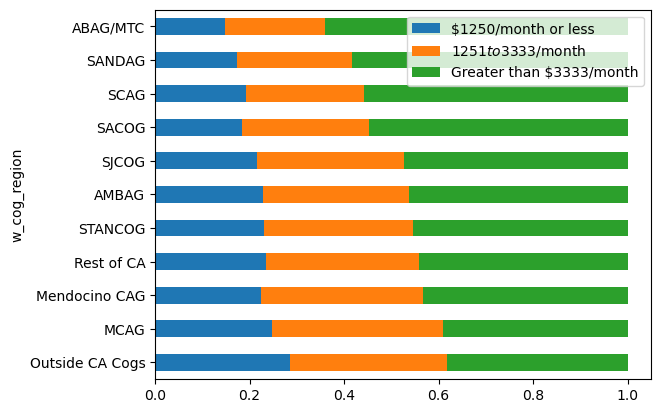

In [14]:
pd.options.display.float_format = '{:,.0%}'.format
# ugh. lets make a readoable plot

se_map = {
    "SE01": "$1250/month or less",
    "SE02": "$1251 to $3333/month",
    "SE03": "Greater than $3333/month"
}

# Ok. The LEHD buckets are really not meaningful anymore - not adjusted since 2010 at least. Nearly 2/3 in top bucket for Bay ARea
(lodes_od
 .query('h_bayarea')
 .groupby('w_cog_region')[['SE01','SE02','SE03']].sum()
 .stack()
 .groupby(level=[0],group_keys=False)
 .apply(pct)
).unstack(1).sort_values('SE03').rename(columns=se_map).plot(kind='barh',stacked=True)

### Aggregate LODES to PUMA-County Level

In [15]:
lodes_agg = aggregate_lodes_to_puma(lodes_od, bay_area_counties)

# Backward-compat aliases (referenced by legacy diagnostic cells)
age_cols      = LODES_AGE_COLS
wage_cols     = LODES_WAGE_COLS
indp_cols     = LODES_INDP_COLS
all_demo_cols = LODES_DEMO_COLS


C:\Users\aolsen\AppData\Local\Temp\ipykernel_15216\743213321.py:216: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  lodes_od.query('(h_bayarea | w_bayarea) & (h_ca & w_ca)')


  Aggregated: 4,131 PUMA-county pairs  |  total jobs: 4,366,194


### Aggregate LODES to match PUMS structure

Since PUMS has full cross-stratification but standard LODES OD files only have *marginal* totals, we'll create a compatible structure by proportionally distributing jobs.

Concenient Simplifying Assumption: Statistical Independence of the three distributions

We know this is not actually true - there is a connection between age, industry and wages of course. But for simplification we just assume equal shares. In other words - this disaggregation pretends that age, earnings, and industry are independent within each PUMA-County pair. (This is essentially the zero-iteration IPF solution - the seed table to start with before any iteration.) Since LODES only provides marginals (not cross-tabs), we cannot do full IPF based on the lodes data alone. We just accept the independence assumption as a convenience approximation, recognizing it will:
- *Under*-estimate combinations where attributes arguably cluster (e.g., young workers in tech) - a pair with a large number of tech workers would probably also be a cell with a higher share of upper income workers.
- *Over*-estimate unlikely combinations where they do not  (e.g., high-wage, agricultural workers)

Of course, we could just derive marginals from the PUMS data and proceed with those. But the K-factors calibrate against PUMS, anyway, which captures the actual cross-tabulated behavioral patterns.

In [16]:
lodes_od_strata = stratify_lodes_od(lodes_agg)
lodes_od_strata.head(5)


  Reconstruction check SE01: 677,057 vs original 677,057  (rel. diff 0.00e+00)
  Stratified OD: 107,688 rows  |  total jobs: 4,366,194


,res_puma,h_counties,w_powpuma,w_counties,age_cat,wage_cat,indp_cat,lodes_jobs
0,0600101,Alameda County,00600100,Alameda County,SA01,SE01,SI01,"5,711%"
1,0600101,Alameda County,00600100,Alameda County,SA01,SE01,SI02,"8,645%"
2,0600101,Alameda County,00600100,Alameda County,SA01,SE01,SI03,"72,789%"
3,0600101,Alameda County,00600100,Alameda County,SA01,SE02,SI01,"7,158%"
4,0600101,Alameda County,00600100,Alameda County,SA01,SE02,SI02,"10,836%"


In [17]:
# Export LODES OD flows
lodes_output = OUT_PATH / f'lodes_{YEAR}_od_puma_powpuma.csv'
lodes_od_strata.to_csv(lodes_output, index=False)
print(f"\nExported LODES OD to: {lodes_output}")


Exported LODES OD to: M:\Projects\Worker Flows\pums_to_lodes_reconciliation\lodes_2019_od_puma_powpuma.csv


## 3. Build Calibration Matrix

### The K-Factors

Creating K-factors: these are calibration coefficients that "reconcile" two data sources:

Definition:
- K = PUMS_commuters / LODES_jobs (stratum-specific)
- Ratio of survey-weighted actual commuters to administrative job counts

Interpretation of K-factor values:
- Topline: (literally) For each OD flow in LODES, what is the relative size of the actually commuting population?
- K about 1.0: PUMS and LODES agree on flow/strata magnitude
- K < 1.0: LODES overcounts relative to PUMS
  - Fewer acualized commute trips than the LODES "on-paper" OD flows
    - Could be because of:
      - Some persons with multiple jobs may be counted multiple times in LODES
      - Survey sampling error or coding error in PUMS
- K > 1.0: PUMS overcounts relative to LODES
  - Fewer "on-paper" OD flows in the LODES data than are actualized in the PUMS data
    - Could be because of:
      - Universe differences (ACS includes self employed workers)
      - PUMS sampling / non-sampling errors
      - Conversely LODES not including self employed workers / gig econmy
      - Geographic or sectoral coding / resolution differences


These K-factors can carry forward a **behavioral signal** on top of the LODES administrative data - allowing for some component behavioral differences by age/wage/industry buckets.

Core expected K-factor patterns:
- Lower K for multi-job sectors (retail, food service)
- Higher K for telecommute-heavy sectors (tech, professional services)
- Variation by age/wage reflects real differences in commute propensity

In [18]:
# Merge PUMS and LODES on common keys
calibration = pd.merge(
    lodes_od_strata,
    pums_od,
    on=['res_puma', 'w_powpuma', 'h_counties',
        'w_counties','age_cat', 'wage_cat', 'indp_cat'],
    how='outer',
    indicator=True
)

# Fill NAs with 0
calibration['pums_commuters'] = calibration['pums_commuters'].fillna(0)
calibration['lodes_jobs'] = calibration['lodes_jobs'].fillna(0)

print(f"\nCalibration matrix: {len(calibration):,} rows")
print(f"\nMerge statistics:")
print(calibration['_merge'].value_counts())


Calibration matrix: 108,396 rows

Merge statistics:
_merge
left_only     102295
both            5393
right_only       708
Name: count, dtype: int64


In [19]:
# Calculate K-factor: Survey commuters / Administrative jobs

# K-factor by stratum allows demographic heterogeneity in commute behavior

calibration['k_factor'] = np.where(
    calibration['lodes_jobs'] > 0,
    calibration['pums_commuters'] / calibration['lodes_jobs'],
    0  # Safe divide here so K=0 means no LODES jobs in particular stratum
)

# Flag cases where PUMS > LODES (K > 1.0)
calibration['pums_exceeds_lodes'] = calibration['pums_commuters'] > calibration['lodes_jobs']

print(f"\nK-factor statistics:")
print(calibration['k_factor'].describe())
print(f"\nCases where PUMS > LODES (K > 1): {calibration['pums_exceeds_lodes'].sum():,}")


K-factor statistics:
count   10,839,600%
mean            19%
std            488%
min              0%
25%              0%
50%              0%
75%              0%
max        114,581%
Name: k_factor, dtype: float64

Cases where PUMS > LODES (K > 1): 3,931


In [20]:
# Export calibration matrix
calib_output = OUT_PATH / f'calibration_matrix_{YEAR}.csv'
calibration.to_csv(calib_output, index=False)
print(f"\nExported calibration matrix to: {calib_output}")

print("\n" + "="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(f"\nOutputs in: {OUT_PATH}")
print(f"  - PUMS OD: {pums_output.name}")
print(f"  - LODES OD: {lodes_output.name}")
print(f"  - Calibration: {calib_output.name}")


Exported calibration matrix to: M:\Projects\Worker Flows\pums_to_lodes_reconciliation\calibration_matrix_2019.csv

DATA PREPARATION COMPLETE

Outputs in: M:\Projects\Worker Flows\pums_to_lodes_reconciliation
  - PUMS OD: pums_2019_od_puma_powpuma.csv
  - LODES OD: lodes_2019_od_puma_powpuma.csv
  - Calibration: calibration_matrix_2019.csv


### Summary Statistics

In [21]:
# Summary by major flows - not surprisingly - top flow is Santa Clara to Santa Clara, high earners, in other services

print("\nTop 10 PUMA-County pairs by PUMS commuters:")
top_pums = calibration.nlargest(10, 'pums_commuters')[
    ['res_puma', 'w_powpuma', 'w_counties','age_cat', 'wage_cat', 'indp_cat', 'pums_commuters', 'lodes_jobs', 'k_factor']
]
print(top_pums.to_string())


Top 10 PUMA-County pairs by PUMS commuters:
      res_puma w_powpuma            w_counties age_cat wage_cat indp_cat  pums_commuters  lodes_jobs  k_factor
83729  0608501  00608500    Santa Clara County    SA02     SE03     SI03      2,634,700%  2,232,081%      118%
69913  0607503  00607500  San Francisco County    SA02     SE03     SI03      2,613,100%  1,832,440%      143%
70958  0607504  00607500  San Francisco County    SA02     SE03     SI03      2,340,700%  1,637,642%      143%
84739  0608502  00608500    Santa Clara County    SA02     SE03     SI03      2,281,000%  1,942,754%      117%
85759  0608503  00608500    Santa Clara County    SA02     SE03     SI03      2,253,800%  1,853,900%      122%
67879  0607501  00607500  San Francisco County    SA02     SE03     SI03      2,236,600%  1,733,836%      129%
68903  0607502  00607500  San Francisco County    SA02     SE03     SI03      1,999,500%  1,493,973%      134%
9714   0600110  00600100        Alameda County    SA02     SE03    

In [22]:
# Aggregate totals for validation
print("\n\n" + "="*60)
print("VALIDATION TOTALS")
print("="*60)

pums_total = calibration['pums_commuters'].sum()
lodes_total = calibration['lodes_jobs'].sum()
overall_k = pums_total / lodes_total if lodes_total > 0 else 0

print(f"\nTotal PUMS Commuters: {pums_total:,.0f}")
print(f"Total LODES Jobs: {lodes_total:,.0f}")
print(f"Overall K-factor: {overall_k:.4f}")

print(f"\n{'='*60}")
print("INTERPRETATION")
print(f"{'='*60}")
print(f"PUMS captures {overall_k*100:.1f}% of LODES jobs as commute trips at the person level.")
print()
print("Why K < 1.0 (LODES > PUMS)?")
print("  • Multiple job holders counted multiple times in LODES (primary issue)")
print("  • Work-from-home workers with recorded job location but no regular commute")
print("  • LODES imputed workplace locations (especially for multi-establishment firms)")
print("  • Side gigs/secondary jobs inflating LODES counts")
print()
print(f"If K = {overall_k:.4f}, this means:")
print(f"  • For every 100 LODES jobs, expect ~{int(overall_k*100)} observed commute trips")
print(f"  • Or: ~{int((1-overall_k)*100)}% of LODES jobs don't generate regular commute trips")
print()
print("The difference could be due to headquarter concentration issues, measurement issues, or")
print("other design differences.")



VALIDATION TOTALS

Total PUMS Commuters: 3,913,254
Total LODES Jobs: 4,366,194
Overall K-factor: 0.8963

INTERPRETATION
PUMS captures 89.6% of LODES jobs as commute trips at the person level.

Why K < 1.0 (LODES > PUMS)?
  • Multiple job holders counted multiple times in LODES (primary issue)
  • Work-from-home workers with recorded job location but no regular commute
  • LODES imputed workplace locations (especially for multi-establishment firms)
  • Side gigs/secondary jobs inflating LODES counts

If K = 0.8963, this means:
  • For every 100 LODES jobs, expect ~89 observed commute trips
  • Or: ~10% of LODES jobs don't generate regular commute trips

The difference could be due to headquarter concentration issues, measurement issues, or
other design differences.


### Bay Area County-Level Flow Comparison

Visualize origin-destination flows at county level for Bay Area (9 counties) across all three data sources.

In [23]:
# 1. PUMS flows aggregated to county level
# Map PUMA to county (using modal county from crosswalk)
pums_county_flows = (
    pums_od
    .assign( # these are kind of silly renames / recodings we could more appropriately handle upstream
        res_county=pums_od.h_counties.str.replace(' County', ''), #pums_od['res_puma'].str[:5].map(ca_county_fips_map),
        work_county=pums_od.w_counties.str.replace(' County', '') 
    )
    #.dropna(subset=['res_county', 'w_powpuma'])  # Keep only Bay Area-Bay Area flows
    .groupby(['res_county', 'work_county'], as_index=False, observed=True)
    ['pums_commuters']
    .sum()
)
# 2. LODES flows aggregated to county level
lodes_county_flows = (
    (lodes_od_strata
    .assign(
        res_county=lodes_od_strata.h_counties.str.replace(' County', ''),
        work_county=lodes_od_strata.w_counties.str.replace(' County', '')
    )
    #.dropna(subset=['res_county'])
    .groupby(['res_county','work_county'], as_index=False, observed=True)
    ['lodes_jobs']
    .sum())
)

# 3. Result: Calibrated flows Applied PUMS derived K-factors to LODES
calibrated_flows = (
    calibration[calibration['lodes_jobs'] > 0]
    .assign(
        calibrated_commuters=calibration['lodes_jobs'] * calibration['k_factor'],
        res_county=calibration.h_counties.str.replace(' County', ''),
        work_county=calibration.w_counties.str.replace(' County', '')
    )
    
    #.dropna(subset=['res_county', 'w_powpuma'])
    .groupby(['res_county', 'work_county'], as_index=False)
    ['calibrated_commuters']
    .sum()
)

print("Bay Area county-level flow matrices prepared:")
print(f"  PUMS: {pums_county_flows['pums_commuters'].sum():,.0f} total commuters")
print(f"  LODES: {lodes_county_flows['lodes_jobs'].sum():,.0f} total jobs")
print(f"  Calibrated: {calibrated_flows['calibrated_commuters'].sum():,.0f} total commuters")

Bay Area county-level flow matrices prepared:
  PUMS: 3,913,254 total commuters
  LODES: 4,366,194 total jobs
  Calibrated: 3,725,354 total commuters


In [24]:
# Create pivot table summaries for heatmaps
pums_matrix = pums_county_flows.pivot(
    index='res_county', 
    columns='work_county', 
    values='pums_commuters'
).reindex(index=county_combo_list, columns=county_combo_list, fill_value=0)

lodes_matrix = lodes_county_flows.pivot(
    index='res_county',
    columns='work_county',
    values='lodes_jobs'
).reindex(index=county_combo_list, columns=county_combo_list, fill_value=0)

calibrated_matrix = calibrated_flows.pivot(
    index='res_county',
    columns='work_county',
    values='calibrated_commuters'
).reindex(index=county_combo_list, columns=county_combo_list, fill_value=0)

# Determine shared color scale for consistency across all plots
disp_scale = 1e3
vmax = max(pums_matrix.div(disp_scale).max().max(), lodes_matrix.div(disp_scale).max().max(), calibrated_matrix.div(disp_scale).max().max())
vmin = 0
print(f"Color scale: {vmin:,.0f} to {vmax:,.0f}")

Color scale: 0 to 809


In [25]:

# Heatmap highlight helper

SHOW_SF_ROW  = True   # thick border around the San Francisco row
SHOW_9X9     = True   # thick border around the 9-county Bay Area block

from matplotlib.patches import Rectangle as _Rect

def _highlight_heatmap(ax, row_labels, highlight_row='San Francisco',
                        n_inner=9, lw=2, color='black',
                        show_row=None, show_block=None):
    """
    Draw emphasis rectangles on a seaborn heatmap after it has been rendered.

    Parameters
    ----------
    ax            : matplotlib Axes containing the heatmap
    row_labels    : ordered list/Index of row labels as displayed
                    (pass county_combo_list; same for all three heatmaps)
    highlight_row : row label to draw a full-width outline around
    n_inner       : leading rows AND columns forming the inner block (default 9)
    lw            : border line width in points
    color         : border colour
    show_row      : override SHOW_SF_ROW if not None
    show_block    : override SHOW_9X9 if not None
    """
    do_row   = SHOW_SF_ROW  if show_row   is None else show_row
    do_block = SHOW_9X9     if show_block is None else show_block

    idx  = list(row_labels)
    ncol = ax.get_xlim()[1]   # seaborn sets xlim exactly to (0, n_cols)
    kw   = dict(linewidth=lw, edgecolor=color, facecolor='none', clip_on=False,
                zorder=5)

    if do_row and highlight_row in idx:
        r = idx.index(highlight_row)
        ax.add_patch(_Rect((0, r), ncol, 1, **kw))

    if do_block:
        ax.add_patch(_Rect((0, 0), n_inner, n_inner, **kw))


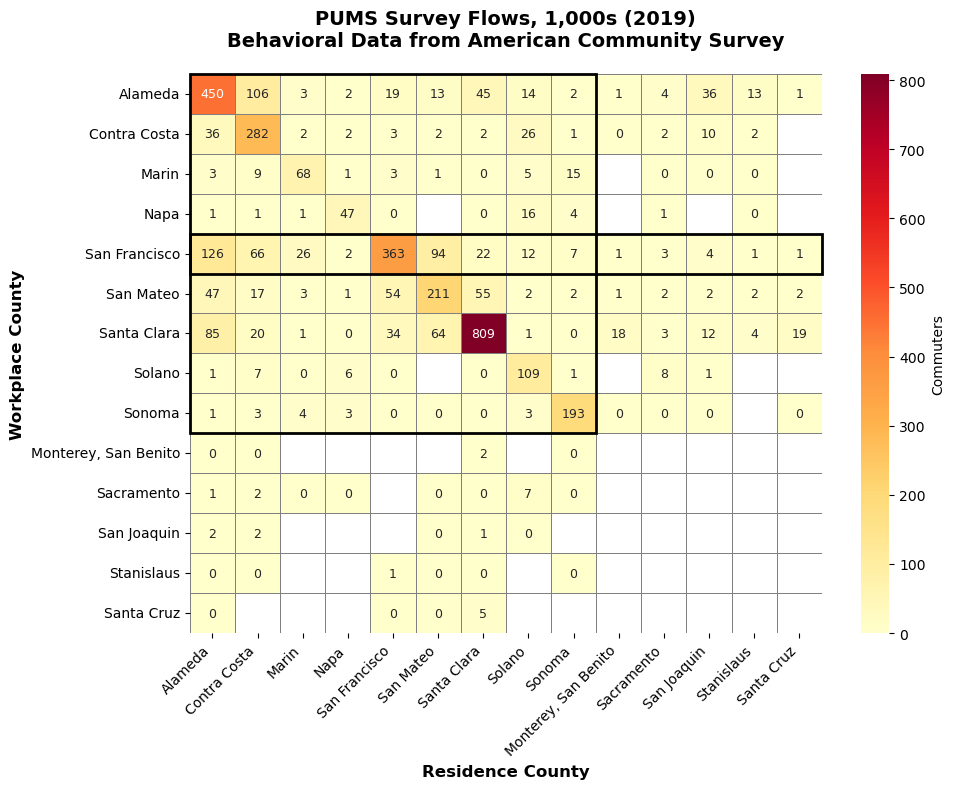

Total PUMS commuters: 3,825,511


In [26]:
# 1. PUMS Survey Flows
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    pums_matrix.div(disp_scale).T, 
    annot=True, 
    fmt='.0f', 
    cmap='YlOrRd',
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'Commuters'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 9}
)
_highlight_heatmap(ax, county_combo_list)
ax.set_title(f'PUMS Survey Flows, 1,000s ({YEAR})\nBehavioral Data from American Community Survey', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Residence County', fontsize=12, fontweight='bold')
ax.set_ylabel('Workplace County', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Total PUMS commuters: {pums_matrix.sum().sum():,.0f}")


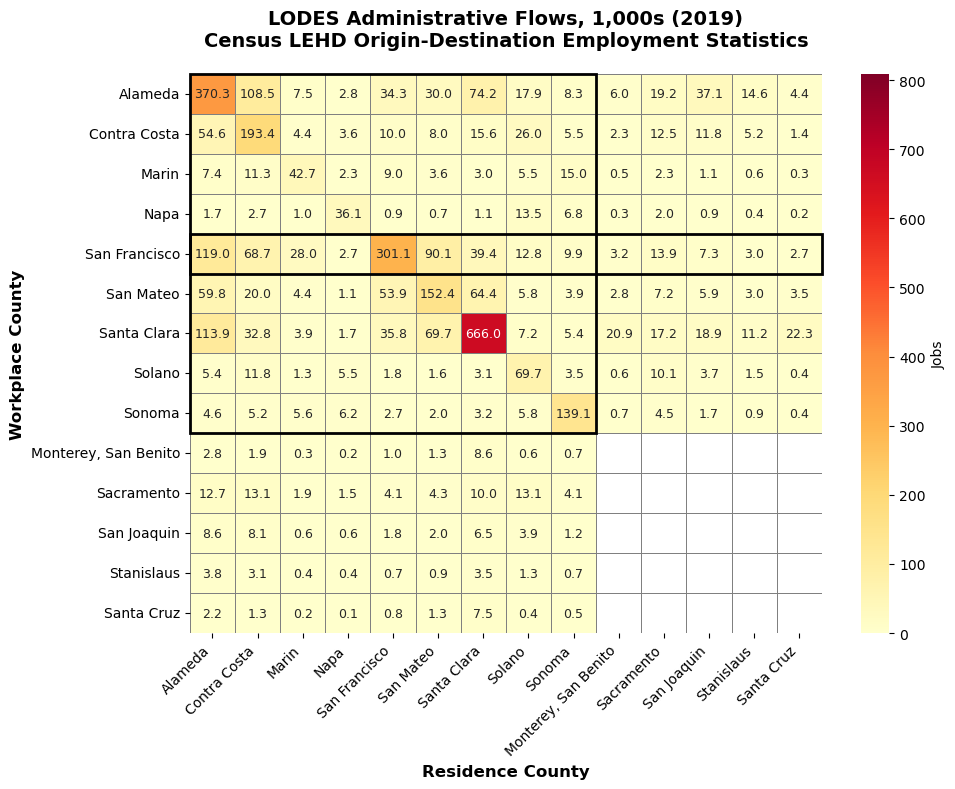

Total LODES jobs: 3,826,273


In [27]:
# 2. LODES Administrative Flows
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    lodes_matrix.div(disp_scale).T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'Jobs'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 9}
)
_highlight_heatmap(ax, county_combo_list)
ax.set_title(f'LODES Administrative Flows, 1,000s ({YEAR})\nCensus LEHD Origin-Destination Employment Statistics', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Workplace County', fontsize=12, fontweight='bold')
ax.set_xlabel('Residence County', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Total LODES jobs: {lodes_matrix.sum().sum():,.0f}")

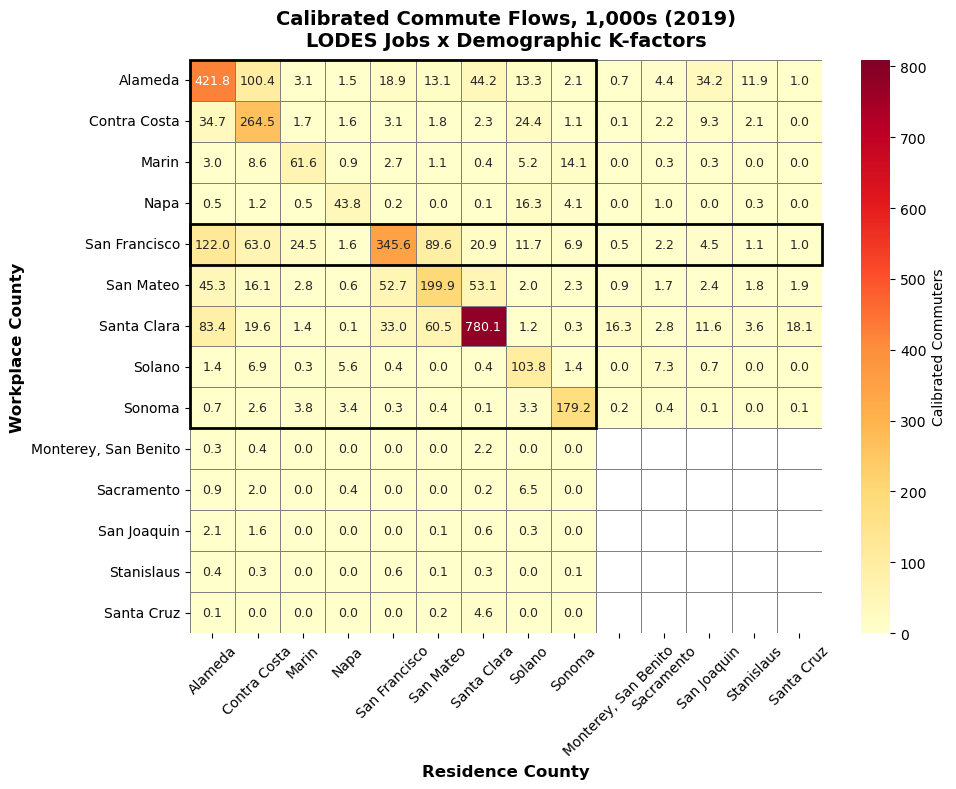

Total calibrated commuters: 3,643,449


In [28]:
# 3. Calibrated Flows (LODES x K-factors)
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    calibrated_matrix.div(disp_scale).T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'Calibrated Commuters'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 9}
)
_highlight_heatmap(ax, county_combo_list)
ax.set_title(f'Calibrated Commute Flows, 1,000s ({YEAR})\nLODES Jobs x Demographic K-factors', 
             fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('Workplace County', fontsize=12, fontweight='bold')
ax.set_xlabel('Residence County', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Total calibrated commuters: {calibrated_matrix.sum().sum():,.0f}")

### Implicit K-factor Map

The implicit K is the blended PUMS/LODES ratio aggregated across all strata at the county-pair level - it is *implicit* because no single cell was set to this value; it falls out of the demographic composition of each OD pair and the underlying stratum K-factors.

It may be useful because it makes the spatial pattern of disagreement between the two sources more immediately legible: cells near 1.0 indicate PUMS and LODES agree on the scale of that flow, while cells well below 1.0 flag where LODES is recording far more job relationships than PUMS observes as actual commute trips (typically halo and cross-regional pairs), and cells above 1.0 flag the reverse (typically within-county diagonals, where gig/self-employed workers and intra-county trips push the PUMS count higher than LODES). This map serves as a visual diagnostic for where the calibration is doing the most work and where the two sources are roughly in accord.


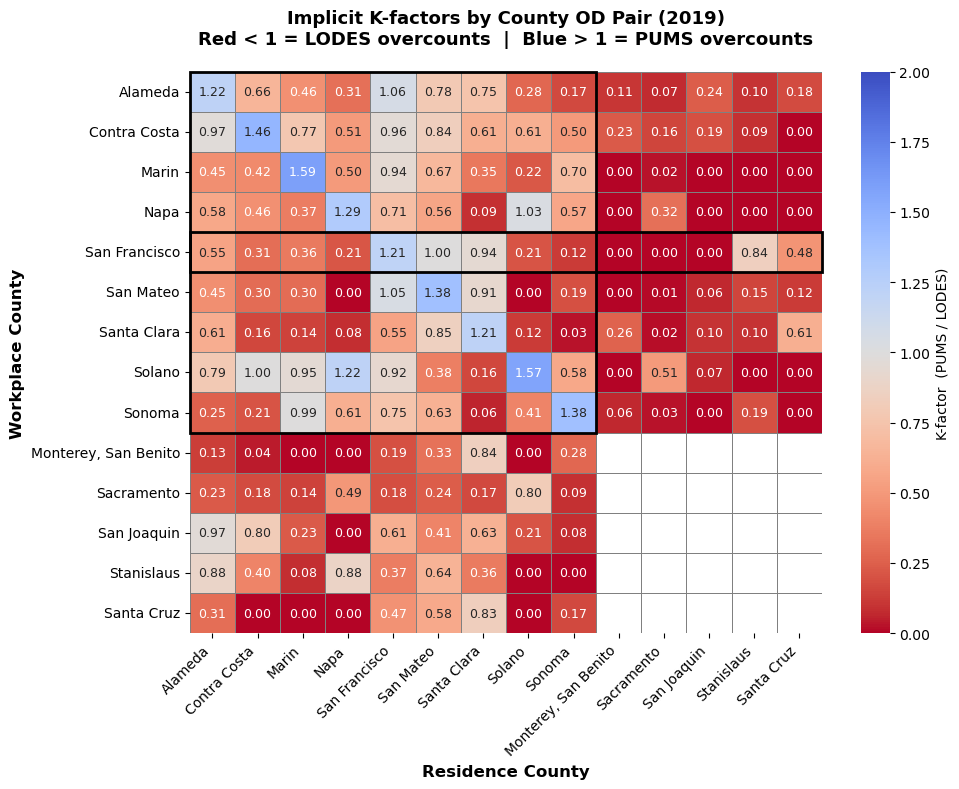

In [29]:

# 4. K-factor heatmap - county-level implicit K = PUMS / LODES
#    (flow-weighted aggregate of stratum K-factors for each OD county pair)

k_county = (
    pums_county_flows
    .merge(lodes_county_flows, on=['res_county', 'work_county'], how='outer')
    .fillna(0)
    .assign(k_county=lambda d: np.where(
        d['lodes_jobs'] > 0,
        d['pums_commuters'] / d['lodes_jobs'],
        np.nan
    ))
)

k_matrix = k_county.pivot(
    index='res_county',
    columns='work_county',
    values='k_county'
).reindex(index=county_combo_list, columns=county_combo_list)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    k_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r',       # red = LODES >> PUMS, blue = PUMS >> LODES
    center=1.0,
    vmin=0,
    vmax=2.0,
    cbar_kws={'label': 'K-factor  (PUMS / LODES)'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 9}
)
_highlight_heatmap(ax, county_combo_list)
ax.set_title(f'Implicit K-factors by County OD Pair ({YEAR})\nRed < 1 = LODES overcounts  |  Blue > 1 = PUMS overcounts',
             fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Workplace County', fontsize=12, fontweight='bold')
ax.set_xlabel('Residence County', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [30]:
# Summary statistics
print("\n" + "="*60)
print("DIAGONAL (Within-County) FLOWS COMPARISON (the BLUE cells above)")
print("="*60)
for county in county_list:
    pums_val = pums_matrix.loc[county, county]
    lodes_val = lodes_matrix.loc[county, county]
    calib_val = calibrated_matrix.loc[county, county]
    k_implicit = pums_val / lodes_val if lodes_val > 0 else 0
    print(f"{county:15s}  PUMS: {pums_val:>8,.0f}  LODES: {lodes_val:>8,.0f}  "
          f"Calibrated: {calib_val:>8,.0f}  (K={k_implicit:.3f})")



DIAGONAL (Within-County) FLOWS COMPARISON (the BLUE cells above)
Alameda          PUMS:  450,201  LODES:  370,307  Calibrated:  421,788  (K=1.216)
Contra Costa     PUMS:  282,285  LODES:  193,439  Calibrated:  264,539  (K=1.459)
Marin            PUMS:   68,083  LODES:   42,730  Calibrated:   61,628  (K=1.593)
Napa             PUMS:   46,553  LODES:   36,098  Calibrated:   43,752  (K=1.290)
San Francisco    PUMS:  363,144  LODES:  301,138  Calibrated:  345,592  (K=1.206)
San Mateo        PUMS:  211,023  LODES:  152,433  Calibrated:  199,908  (K=1.384)
Santa Clara      PUMS:  809,068  LODES:  665,996  Calibrated:  780,072  (K=1.215)
Solano           PUMS:  109,362  LODES:   69,724  Calibrated:  103,789  (K=1.568)
Sonoma           PUMS:  192,623  LODES:  139,123  Calibrated:  179,207  (K=1.385)


In [31]:

# Combine all three county-level flow sources into a single long-format DataFrame
od_keys = ['res_county', 'work_county']

flows_combined = (
    pums_county_flows
    .rename(columns={'pums_commuters': 'PUMS'})
    .merge(
        lodes_county_flows.rename(columns={'lodes_jobs': 'LODES'}),
        on=od_keys, how='outer'
    )
    .merge(
        calibrated_flows.rename(columns={'calibrated_commuters': 'Calibrated'}),
        on=od_keys, how='outer'
    )
    .fillna(0)
    .melt(id_vars=od_keys, var_name='source', value_name='flows')
    .assign(year=YEAR)
    [['year', 'res_county', 'work_county', 'source', 'flows']]
    .sort_values(['res_county', 'work_county', 'source'])
    .reset_index(drop=True)
)

print(f"Combined long-form OD: {len(flows_combined):,} rows")
print(f"Sources: {flows_combined['source'].unique()}")
print(f"OD pairs: {flows_combined[od_keys].drop_duplicates().shape[0]:,}")
flows_combined.head(12)


Combined long-form OD: 1,971 rows
Sources: ['Calibrated' 'LODES' 'PUMS']
OD pairs: 657


,year,res_county,work_county,source,flows
0,2019,Alameda,Alameda,Calibrated,"42,178,800%"
1,2019,Alameda,Alameda,LODES,"37,030,700%"
2,2019,Alameda,Alameda,PUMS,"45,020,100%"
3,2019,Alameda,"Alpine, Amador, Calaveras, Inyo, Mariposa, Mon...",Calibrated,"23,700%"
4,2019,Alameda,"Alpine, Amador, Calaveras, Inyo, Mariposa, Mon...",LODES,"56,400%"
5,2019,Alameda,"Alpine, Amador, Calaveras, Inyo, Mariposa, Mon...",PUMS,"26,600%"
6,2019,Alameda,Butte,Calibrated,0%
7,2019,Alameda,Butte,LODES,"43,100%"
8,2019,Alameda,Butte,PUMS,0%
9,2019,Alameda,"Colusa, Glenn, Tehama, Trinity",Calibrated,0%


In [32]:

# Export for Tableau / other platforms
flows_export_path = OUT_PATH / f'county_od_flows_{YEAR}_long.csv'
flows_combined.to_csv(flows_export_path, index=False)
print(f"Exported to: {flows_export_path}")


Exported to: M:\Projects\Worker Flows\pums_to_lodes_reconciliation\county_od_flows_2019_long.csv


### What PUMS and LODES Are Each Telling Us

Revisting key data considerations / measurement issues:

- **Multiple job holders** are counted once per each job in LODES, inflating the denominator relative to the one ACS household survey respondent who holds both jobs. This applies throughout, but the effect is diffuse and not primarily geographic.
- **Work-from-home recoding**: The Census Bureau records a WFH respondent's POWPUMA based on their home address, obscuring the employer location. LODES still records the administrative work site address - and as work-from-home has risen past 20 percent of the workforce, this increasingly censors the long-distance employment relationships that LODES retains. A worker in Sacramento with a San Francisco employer is counted in LODES as an SF job; the ACS does not record them as an SF commuter.
- **Gig / self-employed workers** appear in PUMS but are out of scope in the LODES universe, anchored to UI-covered wage/salary employment. To the extent these workers commute locally, PUMS captures additional internal-region trips that LODES misses - contributing to K > 1 on the diagonal.
- **On-paper remote relationships**: We have separately observed a secular increase in LODES flows originating from outside the Bay Area - Sacramento, the Central Valley, and beyond - that do not appear to have grown commensurately in travel counts or employment surveys. These are long-distance employer-employee records that never translate into trips.

#### Headline findings and tiers: The K factor differences are not uniform across geography
The tiered summary cell below separates the 9x9 Bay Area internal matrix (Bay Area resident -> Bay Area workplace) from the cross-regional and halo flows (any OD pair with at least one end outside the nine counties). The split is striking:

| Scope | PUMS | LODES | K |
|---|---:|---:|---:|
| 9x9 Bay Area internal | 3,645,270 | 3,391,463 | **1.075** |
| Cross-region & halo flows | 180,241 | 434,810 | **0.415** |
| Full matrix (county combo list) | 3,825,511 | 3,826,273 | **1.000** |

- **Internal Bay Area flows**: K = 1.075 - While LODES has potential for double counting and thereby potentially inflating numbers, PUMS *exceeds* LODES even with the removal of work from home residents from the universe (but pointing in the other direction, is the inclusion of self employed workers not captured in the LODES universe). Intra-regional commutes are reasonably well-captured by both ACS and LODES. The diagonal (within-county cells) is where the difference between the two is most pronounced - with PUMS capturing a notably larger share here. The county-pair K-factor heatmap makes the spatial pattern visible: **the main diagonal (within-county OD cells) consistently shows K > 1**, while the off-diagonal - cross-county and cross-region - runs the other way. LODES perceives the Bay Area economy as structurally more **"leaky"** than PUMS does: more jobs officially located outside the county of residence, more employment relationships extending to distant halo counties, more administrative anchoring to headquarters addresses that workers never regularly visit.
- **Cross-region / halo flows**: K = 0.415 - LODES records more than twice as many job relationships as PUMS observes as actual commutes. This is where the "on-paper" employment relationships arguably either floods the administrative data, or conversely are just mis-classified in the PUMS data because a Sacramento resident working for a San Francisco firm - but working remotely - would not show up in the PUMS data in the Sacramento-SF cell but **would** in principle be covered in LODES.
- **Full matrix**: K ≈ 1.00 - roughly at parity once restricted to the county combination list (Bay Area + selected halo counties). Note the broader overall K cited in the validation cell above (~0.89) reflects a wider geographic scope including all California county pairs touching the Bay Area - the added long-distance flows drag it further below 1.

The practical read: LODES does not uniformly overcount the Bay Area labor market (when including origins outside the region). It rather presents a world in which the hinterlad "*reach*" of the regional economy is larger - logging employment relationships at geographic distances that PUMS respondents do not report as commutes to the region.

This also practically means for the k-factors for calibration that the *K* heterogeneity clearly means the stratification is practically useful (whether we got just the right one is another matter). A single aggregate K would over-correct the short internal flows and under-correct the long-distance ones. 

The stratum-level K-factors computed here - indexed to PUMA x POWPUMA x age x wage x industry - capture spatial and demographic heterogeneity.

In [33]:
# Two-tier K-factor: Bay Area 9x9 internal vs full calibration matrix
bay9 = county_list  # alias for 9 Bay Area counties defined in setup

pums_9x9   = pums_matrix.loc[bay9, bay9].sum().sum()
lodes_9x9  = lodes_matrix.loc[bay9, bay9].sum().sum()
k_9x9      = pums_9x9 / lodes_9x9

pums_full  = pums_matrix.sum().sum()
lodes_full = lodes_matrix.sum().sum()
k_full     = pums_full / lodes_full

pums_xreg  = pums_full  - pums_9x9
lodes_xreg = lodes_full - lodes_9x9
k_xreg     = pums_xreg / lodes_xreg if lodes_xreg > 0 else np.nan

print("K-factor by geographic scope  (PUMS commuters / LODES jobs)")
print("=" * 65)
print(f"{'Scope':<35} {'PUMS':>10}  {'LODES':>10}  {'K':>6}")
print("-" * 65)
print(f"{'9x9 Bay Area internal':<35} {pums_9x9:>10,.0f}  {lodes_9x9:>10,.0f}  {k_9x9:>6.3f}")
print(f"{'Cross-region & halo flows':<35} {pums_xreg:>10,.0f}  {lodes_xreg:>10,.0f}  {k_xreg:>6.3f}")
print(f"{'Full matrix':<35} {pums_full:>10,.0f}  {lodes_full:>10,.0f}  {k_full:>6.3f}")

K-factor by geographic scope  (PUMS commuters / LODES jobs)
Scope                                     PUMS       LODES       K
-----------------------------------------------------------------
9x9 Bay Area internal                3,645,270   3,391,463   1.075
Cross-region & halo flows              180,241     434,810   0.415
Full matrix                          3,825,511   3,826,273   1.000


## 4. WFH Adjustment to K-Factors

### Motivation

The K-factors derived above encode **2019 commute behavior** - the ratio of PUMS-observed trips to LODES administrative job relationships in a pre-pandemic year. While that is by design - to capture the PUMS behavior before we lose precision to WFH - applying the 2019-derived K-factors to a current-year LODES dataset implicitly assumes that 2019 commute "realization rates" (the fraction of LODES job relationships that become observed commute trips) still hold. That assumption is not without problems:

- **WFH share has risen materially since 2019.** SWAA tracking surveys suggest about 12% of U.S. workers are now fully remote with another ~24% hybrid; Bay Area shares are higher given the industry composition. Each percentage-point increase in WFH within a stratum means fewer LODES job relationships generate actual trips, so $K_{2019}$ will overstate trip generation if applied directly to post-pandemic LODES.
- **POWPUMA recoding for WFH respondents** (introduced systematically post-2020) means we cannot directly re-estimate OD K-factors from post-2019 PUMS - respondents working from home have their POWPUMA set to their home PUMA, destroying the cross-county behavioral signal. 
- **However, JWTR (transport mode = 11, "worked from home") is still observed** and tells us something useful about the WFH subset - notwithstanding not being able to use the workplace geography information from these records. But, we can still characterize work from homers by their demographic and industry attributes - age, earnings, industry stratum - even though we no longer observe the employer location they would have commuted to. That is enough to measure *how much* WFH has grown within each stratum, which is what the adjustment requires.

### Approach

For each stratum (age x wage x industry):

$$K_{\text{adj}} = K_{2019} \times \frac{1 - \text{WFH}_{t}}{1 - \text{WFH}_{2019}}$$

The ratio $(1 - \text{WFH}_t) / (1 - \text{WFH}_{2019})$ is a **mobility retention factor** - the fraction of 2019 commuter propensity that survives the higher WFH share. A stratum that went from 5% WFH to 30% WFH sees its mobility rate fall from 95% to 70%, so $K_{\text{adj}} \approx 0.74 \times K_{2019}$.

Strata with already-high WFH in 2019 (tech, professional services - SI03 x SE03) see the largest adjustments; goods-producing and low-wage strata (SI01 x SE01) need minimal correction.

### Identifying Assumptions

The formula is internally consistent but rests on two assumptions worth naming:

**1. The non-WFH conditional trip rate is held fixed at 2019 levels.**

The formula holds constant the rate at which *non-WFH* workers (JWTR ≠ 11) generate commute trips - i.e., conditional on a worker not self-reporting WFH on the survey day, a LODES job is assumed as likely in year $t$ as in 2019 to produce an observed trip. This is violated in two opposite directions:

- *Hybrid work* (the dominant post-pandemic modality) is classified JWTR ≠ 11 on a survey weekday, but hybrid workers commute 2–3 days/week rather than 5. Their conditional trip rate is lower than a full-time in-office worker. **This means the formula understates the true commute reduction** - observed trips fell by more than the WFH share alone implies.
- *Selection*: if workers with the lowest commute propensity shifted to WFH first, the remaining non-WFH workers have a higher average conditional trip rate, which would cause the formula to overstate the reduction. This is the smaller and harder-to-observe effect.

On balance, because hybrid work dominates fully-remote WFH, the formula should be treated as a **lower bound on the commute decline**: the actual 2023 trip rate is likely somewhat below $K_{2019} \times \text{retention}$, not equal to it.

**2. Bay Area resident WFH rates proxy for all inbound workers.**

The retention factors are estimated from Bay Area *resident* JWTR responses. But the K-factors cover all OD pairs, including inbound halo flows (e.g., Sacramento -> SF) where the commuting worker lives outside the nine-county region. For those pairs, we apply Bay Area resident WFH growth to a workforce that may have different propensities. Since Bay Area firms drove much of the remote-work shift, their workforce broadly - wherever it lives - likely experienced elevated WFH growth, but this remains an assumption that may **slightly overstate the WFH correction for inbound flows** from counties where remote-work norms differ.

**Note on scope**: This adjustment corrects commute *propensity* only. It does not adjust for changes in the LODES administrative flows themselves (e.g., growth in remote cross-regional job relationships that inflate the 2023 denominator). That remains a separate and unresolved source of uncertainty, discussed in the wrap-up.


In [34]:
# 2019 WFH baseline - reuse already-loaded pums (full employed universe, including WFH respondents)
print(f"Computing WFH shares for {YEAR} (baseline)...")
wfh_2019 = compute_wfh_shares(pums, puma_county_xwalk, bay_area_counties, year_label=YEAR)

print(f"\nBy strata - top 10 by WFH share:")
print(wfh_2019.sort_values(f'wfh_share_{YEAR}', ascending=False).head(10).to_string(index=False))


Computing WFH shares for 2019 (baseline)...


  Bay Area employed: 3,872,414  |  WFH: 200,745 (5.2%)

By strata - top 10 by WFH share:
age_cat wage_cat indp_cat  total_employed_2019  wfh_workers_2019  wfh_share_2019
   SA03     SE01     SI03                73432              9980             14%
   SA03     SE02     SI03               108611             10381             10%
   SA02     SE01     SI03               118009              9469              8%
   SA03     SE03     SI03               358656             27611              8%
   SA03     SE03     SI01               107990              6839              6%
   SA03     SE02     SI01                24483              1479              6%
   SA02     SE03     SI03              1125173             66693              6%
   SA03     SE01     SI01                 8236               485              6%
   SA03     SE01     SI02                20886              1208              6%
   SA02     SE02     SI03               232843             12919              6%


In [35]:
WFH_YEAR = 2023  # any available PUMS year >2020

# Select the PUMA->county crosswalk appropriate for the target year's vintage
# (2022+ PUMS use 2020-based PUMAs; pre-2022 use 2010-based)
if WFH_YEAR >= 2022:
    wfh_puma_xwalk = pd.read_csv(
        CROSSWALK_PATH / 'stpuma_to_county_2024.csv', dtype=str
    ).set_index('STPUMA')
else:
    wfh_puma_xwalk = puma_county_xwalk

print(f"Computing WFH shares for {WFH_YEAR}...")
wfh_current = compute_wfh_shares(WFH_YEAR, wfh_puma_xwalk, bay_area_counties, year_label=WFH_YEAR)

print(f"\nBy strata - top 10 by WFH share:")
print(wfh_current.sort_values(f'wfh_share_{WFH_YEAR}', ascending=False).head(10).to_string(index=False))


Computing WFH shares for 2023...
  psam_pusa.csv
  psam_pusb.csv
  -> 3,405,809 records loaded (2023)
  Bay Area employed: 3,730,008  |  WFH: 647,413 (17.4%)

By strata - top 10 by WFH share:
age_cat wage_cat indp_cat  total_employed_2023  wfh_workers_2023  wfh_share_2023
   SA02     SE03     SI03              1180973            285074             24%
   SA03     SE03     SI03               384439             86573             23%
   SA01     SE03     SI03               270908             49434             18%
   SA03     SE01     SI03                65562             11666             18%
   SA02     SE03     SI02               200791             33002             16%
   SA03     SE02     SI03                91450             14618             16%
   SA03     SE03     SI01               130769             20399             16%
   SA03     SE01     SI01                 7591              1143             15%
   SA02     SE01     SI03                95004             13862             15

In [36]:
# --- Compute strata-level K adjustment factors ---
#
# K_adj = K_base x (1 - wfh_current) / (1 - wfh_base)
#
# Interpretation:
#   k_adj_factor < 1  ->  WFH share grew; K_base overstates current commute propensity
#   k_adj_factor = 1  ->  WFH unchanged; K_base still applies directly
#   k_adj_factor > 1  ->  WFH declined (unlikely post-pandemic)

strata_keys  = ['age_cat', 'wage_cat', 'indp_cat']
col_base     = f'wfh_share_{YEAR}'
col_current  = f'wfh_share_{WFH_YEAR}'
col_emp_base = f'total_employed_{YEAR}'

wfh_adj = wfh_2019.merge(
    wfh_current[strata_keys + [col_current, f'total_employed_{WFH_YEAR}']],
    on=strata_keys, how='left'
)

wfh_adj['k_adj_factor'] = (1 - wfh_adj[col_current]) / (1 - wfh_adj[col_base])
wfh_adj['wfh_delta_pp'] = (wfh_adj[col_current] - wfh_adj[col_base]) * 100

pd.options.display.float_format = '{:.3f}'.format

print(f"K adjustment factors  ({YEAR} -> {WFH_YEAR}, Bay Area residents)")
print(f"multiply K_{YEAR} by k_adj_factor when applying to {WFH_YEAR} LODES\n")
print(
    wfh_adj[strata_keys + [col_base, col_current, 'wfh_delta_pp', 'k_adj_factor']]
    .sort_values('k_adj_factor')
    .to_string(index=False)
)

# Apply to calibration matrix
calibration_adj = calibration[calibration['lodes_jobs'] > 0].merge(
    wfh_adj[strata_keys + ['k_adj_factor']], on=strata_keys, how='left'
)
calibration_adj['k_factor_adj'] = (
    calibration_adj['k_factor'] * calibration_adj['k_adj_factor'].fillna(1.0)
)

print(f"\nK-factor distribution before and after WFH adjustment:")
comp = pd.DataFrame({
    f'k_factor_{YEAR}':     calibration_adj['k_factor'].describe(),
    f'k_factor_{WFH_YEAR}': calibration_adj['k_factor_adj'].describe(),
})
print(comp.loc[['mean', '50%', 'std', 'min', 'max']].to_string())


K adjustment factors  (2019 -> 2023, Bay Area residents)
multiply K_2019 by k_adj_factor when applying to 2023 LODES

age_cat wage_cat indp_cat  wfh_share_2019  wfh_share_2023  wfh_delta_pp  k_adj_factor
   SA02     SE03     SI03           0.059           0.241        18.212         0.806
   SA01     SE03     SI03           0.025           0.182        15.720         0.839
   SA03     SE03     SI03           0.077           0.225        14.821         0.839
   SA02     SE03     SI02           0.044           0.164        12.066         0.874
   SA01     SE03     SI02           0.018           0.120        10.276         0.895
   SA02     SE03     SI01           0.034           0.132         9.851         0.898
   SA03     SE03     SI01           0.063           0.156         9.266         0.901
   SA03     SE01     SI01           0.059           0.151         9.169         0.903
   SA01     SE03     SI01           0.014           0.108         9.431         0.904
   SA02     SE01     S

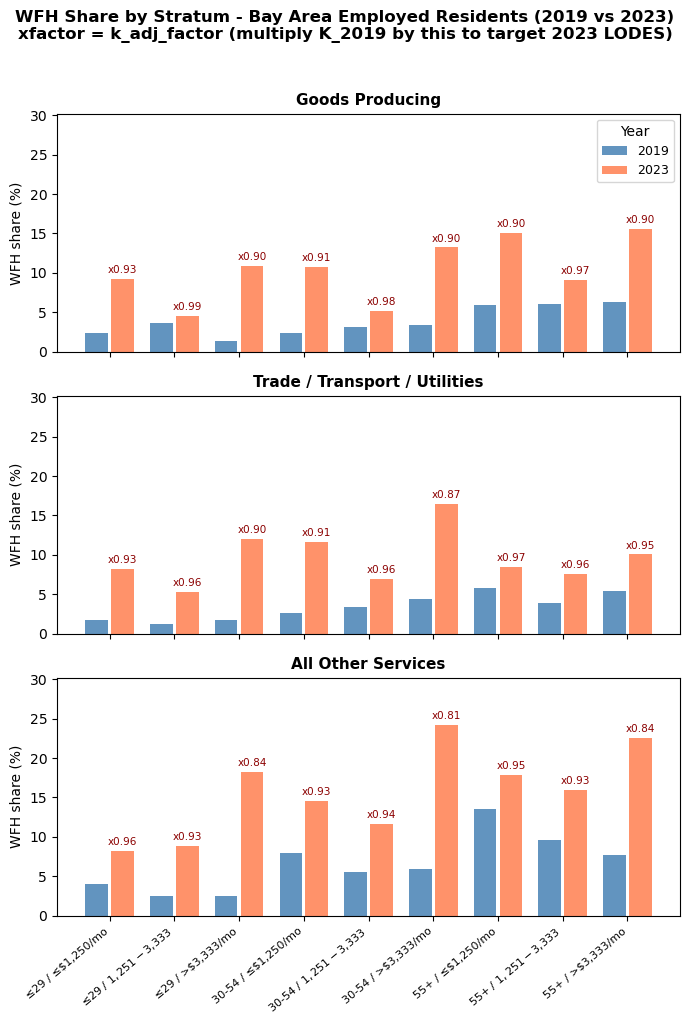

Overall mobility retention factor (pop-weighted): 0.878


In [37]:
# Now visualize WFH change and k_adj_factor by stratum
indp_labels  = {'SI01': 'Goods Producing', 'SI02': 'Trade / Transport / Utilities', 'SI03': 'All Other Services'}
age_labels   = {'SA01': '≤29', 'SA02': '30-54', 'SA03': '55+'}
wage_labels  = {'SE01': '≤$1,250/mo', 'SE02': '$1,251-$3,333', 'SE03': '>$3,333/mo'}

col_base    = f'wfh_share_{YEAR}'
col_current = f'wfh_share_{WFH_YEAR}'

wfh_plot = wfh_adj.copy()
wfh_plot['indp_label']   = wfh_plot['indp_cat'].map(indp_labels)
wfh_plot['strata_label'] = (wfh_plot['age_cat'].map(age_labels).astype(str)
                            + ' / ' + wfh_plot['wage_cat'].map(wage_labels).astype(str))

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

for ax, indp in zip(axes, ['SI01', 'SI02', 'SI03']):
    sub = wfh_plot[wfh_plot['indp_cat'] == indp].copy()
    x   = range(len(sub))

    ax.bar([i - 0.2 for i in x], sub[col_base] * 100,    width=0.35,
           label=str(YEAR), color='steelblue', alpha=0.85)
    ax.bar([i + 0.2 for i in x], sub[col_current] * 100, width=0.35,
           label=str(WFH_YEAR), color='coral', alpha=0.85)

    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(i + 0.2, row[col_current] * 100 + 0.5,
                f"x{row['k_adj_factor']:.2f}", ha='center', va='bottom',
                fontsize=7.5, color='darkred')

    ax.set_xticks(list(x))
    ax.set_xticklabels(sub['strata_label'].tolist(), rotation=40, ha='right', fontsize=8)
    ax.set_title(indp_labels[indp], fontsize=11, fontweight='bold')
    ax.set_ylabel('WFH share (%)')
    ax.set_ylim(0, max(wfh_plot[col_current].max() * 100 * 1.25, 10))
    if ax == axes[0]:
        ax.legend(title='Year', fontsize=9)

fig.suptitle(
    f'WFH Share by Stratum - Bay Area Employed Residents ({YEAR} vs {WFH_YEAR})\n'
    f'xfactor = k_adj_factor (multiply K_{YEAR} by this to target {WFH_YEAR} LODES)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Population-weighted overall mobility retention factor
emp_base   = f'total_employed_{YEAR}'
print(f"Overall mobility retention factor (pop-weighted): "
      f"{((1 - wfh_adj[col_current]) / (1 - wfh_adj[col_base]) * wfh_adj[emp_base]).sum() / wfh_adj[emp_base].sum():.3f}")


### Upshot: Reading the Mobility Retention Factor

#### What `k_adj_factor` actually measures

The bar charts annotate each stratum with a multiplier of the form `x0.84`. This is the **mobility retention factor**:

$$\text{retention} = \frac{1 - \text{WFH}_{t}}{1 - \text{WFH}_{2019}}$$

It is **not** the WFH share itself. It is the fraction of the 2019 commuter base that still commutes in year $t$. Concretely:

> *A factor of 0.84 means: for every 100 workers in this stratum who commuted in 2019, 84 still do. The remaining 16 have shifted to working from home.*

The number $1 - \text{retention}$ is the **proportional reduction in commute trip generation**, not the current WFH share. The current WFH share is recovered as $1 - \text{retention} \times (1 - \text{WFH}_{2019})$.

**Example - SI03 / SA03 / SE03 (All Other Services, age 55+, >$3,333/mo):**

If this stratum had, say, 8% WFH in 2019 and 22.5% in the target year, then:

$$\text{retention} = \frac{1 - 0.225}{1 - 0.08} = \frac{0.775}{0.920} \approx 0.84$$

#### What it means:
Reading this out: *in 2019, 92 of every 100 workers in this group commuted; by the target year only ~77.5 do - so the stratum generates ~16% fewer commute trips than it did pre-pandemic.*

The `k_factor_adj` for this stratum is then $K_{2019} \times 0.84$ - meaning every 100 LODES jobs in this cell now implies approximately $K_{2019} \times 84$ observed commute trips rather than $K_{2019} \times 100$.

#### What this analysis can say - and what it cannot

**Can say:**

- **How much WFH has grown, by strata.** JWTR=11 is a reliable self-report unaffected by the post-2020 POWPUMA recoding. We can measure the demographic shape of WFH growth (high-earners in services grew fastest; goods-producing and low-wage barely moved) with reasonable ACS precision.
- **Proportional trip-generation decay by stratum.** The retention factor translates directly into a scale adjustment on each demographic cell of the K-factor matrix. The adjustment is internally consistent with the 2019 calibration.
- **Relative ordering of strata by WFH risk.** High-income services workers in middle-and-older age cohorts have the largest WFH adjustment factors; this is directionally consistent with independent telework surveys (SWAA, BLS ATUS).

**Cannot say:**

- **Where the non-commuting workers' jobs are actually located.** The POWPUMA recoding strips the geographic signal for WFH respondents in post-2019 PUMS. We know *that* these workers have shifted away from commuting; we do not know whether their employers are in San Francisco, South Bay, or elsewhere. The spatial K-factor topology (which OD cell carries what factor) cannot be updated from post-2020 PUMS alone - only the *magnitude* of each cell's K can be scaled.
- **Whether those workers have physically moved.** A WFH worker whose POWPUMA is now coded to their home address might have relocated to Sacramento, or might still live in San Jose. PUMS migration tables can partially address this but add another layer of measurement uncertainty.
- **How the LODES cross-regional flows have changed.** The secular growth in long-distance LODES job relationships (the K < 1 halo problem discussed in the wrap-up) could be worsening, stabilizing, or partially reversing as some firms require return-to-office. The retention factor corrects the *commuter-rate* half of the K calculation; it does not address potential growth in the *denominator* (LODES jobs) due to remote-hire geographic spread. These two effects can compound or partially offset each other.

#### Bottom line for downstream use

The WFH-adjusted K-factors (`k_factor_adj`) are the right choice when applying the 2019 calibration to a post-pandemic LODES dataset. They encode:

1. The 2019 behavioral signal (who commutes where, by stratum) - from PUMS OD
2. The 2019-to-target-year reduction in commute propensity - from JWTR WFH shares

What they do **not** encode is updated *geography* of commuting. The stratum totals are scaled correctly, but the spatial distribution within each stratum still reflects 2019 patterns. For travel modeling purposes, this is likely acceptable for short-distance internal-region flows (where the 2019 K already approximated parity), but will overstate the halo and cross-regional flows if remote hiring has continued to expand the LODES denominator.


In [38]:
# Export WFH-adjusted calibration matrix
calib_adj_output = OUT_PATH / f'calibration_matrix_{YEAR}_wfh_adj_{WFH_YEAR}.csv'
calibration_adj[
    ['res_puma', 'h_counties', 'w_powpuma', 'w_counties',
     'age_cat', 'wage_cat', 'indp_cat',
     'lodes_jobs', 'pums_commuters',
     'k_factor', 'k_adj_factor', 'k_factor_adj']
].to_csv(calib_adj_output, index=False)
print(f"Exported WFH-adjusted calibration matrix to: {calib_adj_output}")
print(f"\nColumns:")
print(f"  k_factor      - original 2019 PUMS/LODES K")
print(f"  k_adj_factor  - WFH mobility retention multiplier (2019->{WFH_YEAR})")
print(f"  k_factor_adj  - k_factor x k_adj_factor  (apply this to {WFH_YEAR} LODES)")


Exported WFH-adjusted calibration matrix to: M:\Projects\Worker Flows\pums_to_lodes_reconciliation\calibration_matrix_2019_wfh_adj_2023.csv

Columns:
  k_factor      - original 2019 PUMS/LODES K
  k_adj_factor  - WFH mobility retention multiplier (2019->2023)
  k_factor_adj  - k_factor x k_adj_factor  (apply this to 2023 LODES)


## 5. "Out-of-Sample" Application: 2023 LODES with WFH-Adjusted K-Factors

Load 2023 LODES, run it through the same aggregation/stratification pipeline, then apply
`k_factor_adj` (= K_2019 x mobility-retention-factor_2023) to produce estimated 2023 commute
flows. This is "out of sample" in the sense that no 2023 behavioral data (PUMS OD) was used
to set the K-factors - the adjustment is driven purely by the change in WFH shares between 2019
and 2023 observed in the JWTR variable.

**Merge logic**:
- *Matched OD pairs* (present in the 2019 calibration): use the full `k_factor_adj`
  (2019 PUMS/LODES ratio x stratum retention factor)
- *New 2023-only OD pairs*: fall back to a **tier-specific** geographic K x stratum retention factor:
  - Both ends inside the 9-county Bay Area -> use `k_9x9` ≈ 1.075
  - At least one end outside the 9 counties -> use `k_xreg` ≈ 0.454

  Using tier-specific fallbacks (rather than the single `overall_k` ≈ 0.89) avoids systematically
  under-scoring new internal Bay Area pairs and over-scoring new halo pairs, which would be the
  result of mixing two very different geographic regimes into one average.


In [ ]:
# ── Step 5a: Load and process 2023 LODES ─────────────────────────────────────
# WFH_YEAR is already set to 2023 above.
# The same xwalks (2019 vintage / 2020 blocks) are used because:
#   • LODES V8 uses 2020 census blocks for ALL data years
#   • k_factor_adj keys are indexed to puma19 / POWSTPUMA_2019 geography

print(f"Loading LODES {WFH_YEAR}...")
lodes_od_2023 = load_lodes_od('ca', WFH_YEAR)

print(f"\nTagging geography...")
lodes_od_2023 = tag_lodes_geography(lodes_od_2023, xwalks, bay_area_counties, cog_regions)

print(f"\nAggregating to PUMA level...")
lodes_agg_2023 = aggregate_lodes_to_puma(lodes_od_2023, bay_area_counties)

print(f"\nStratifying into age x wage x industry cells...")
lodes_od_strata_2023 = stratify_lodes_od(lodes_agg_2023)


Loading LODES 2023...
  Loading ca_od_main_JT00_2023.csv.gz…


  Loading ca_od_aux_JT00_2023.csv.gz…
  -> 16,459,710 records  |  S000=17,855,349

Tagging geography...
  h_puma matched:    16,241,068/16,459,710  (98.7 %)
  w_powpuma matched: 16,459,710/16,459,710  (100.0 %)

Aggregating to PUMA level...


C:\Users\aolsen\AppData\Local\Temp\ipykernel_15216\743213321.py:216: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  lodes_od.query('(h_bayarea | w_bayarea) & (h_ca & w_ca)')


  Aggregated: 4,128 PUMA-county pairs  |  total jobs: 4,413,017

Stratifying into age × wage × industry cells...
  Reconstruction check SE01: 530,482 vs original 530,482  (rel. diff 0.00e+00)
  Stratified OD: 107,624 rows  |  total jobs: 4,413,017


In [ ]:
# Step 5b: Apply k_factor_adj to 2023 LODES
#
# Merge strategy (left join on full ODxstratum keys):
#   • Matched OD pairs     -> k_factor_adj from calibration_adj
#                            (2019 PUMS/LODES ratio x stratum retention factor)
#   • New 2023-only pairs  -> tier-specific fallback K x k_adj_factor(stratum)
#
# Fallback uses the two-tier Ks from section 3 rather than the single overall_k,
# because internal Bay Area pairs run at K≈1.075 while cross-regional pairs run
# at K≈0.454 - blending them with overall_k would under-score new internal pairs
# and over-score new halo pairs.

od_strata_keys = ['res_puma', 'h_counties', 'w_powpuma', 'w_counties',
                  'age_cat', 'wage_cat', 'indp_cat']

adj_lookup = calibration_adj[od_strata_keys + ['k_factor_adj']].drop_duplicates(od_strata_keys)

lodes_2023_adj = (
    lodes_od_strata_2023
    .merge(adj_lookup, on=od_strata_keys, how='left')
    # pull in the stratum-level retention factor for the fallback
    .merge(wfh_adj[strata_keys + ['k_adj_factor']], on=strata_keys, how='left')
)

n_total   = len(lodes_2023_adj)
n_matched = lodes_2023_adj['k_factor_adj'].notna().sum()
n_new     = n_total - n_matched

# Tier-specific fallback Ks for new OD pairs
#   k_9x9  ≈ 1.075  (both ends in the 9-county Bay Area)
#   k_xreg ≈ 0.454  (at least one end outside the 9 counties)
_bay9_set = set(bay_area_counties.values())   # county names, e.g. {'Alameda', 'San Francisco', ...}
_h_in_bay = lodes_2023_adj['h_counties'].str.replace(' County', '').isin(_bay9_set)
_w_in_bay = lodes_2023_adj['w_counties'].str.replace(' County', '').isin(_bay9_set)
_fallback_k = np.where(_h_in_bay & _w_in_bay, k_9x9, k_xreg)

lodes_2023_adj['k_factor_used'] = lodes_2023_adj['k_factor_adj'].fillna(
    _fallback_k * lodes_2023_adj['k_adj_factor']
)
lodes_2023_adj['k_fallback_tier'] = np.where(
    lodes_2023_adj['k_factor_adj'].notna(), 'matched',
    np.where(_h_in_bay & _w_in_bay, 'internal_fallback', 'xreg_fallback')
)

lodes_2023_adj['adjusted_commuters'] = lodes_2023_adj['lodes_jobs'] * lodes_2023_adj['k_factor_used']

# Shares by match type
jobs_matched = lodes_2023_adj.loc[lodes_2023_adj['k_factor_adj'].notna(), 'lodes_jobs'].sum()
jobs_new     = lodes_2023_adj.loc[lodes_2023_adj['k_factor_adj'].isna(),  'lodes_jobs'].sum()

pd.options.display.float_format = '{:,.1f}'.format
print(f"ODxstratum rows:  {n_total:,}  total")
print(f"  matched to 2019 calibration: {n_matched:,}  ({100*n_matched/n_total:.1f}%)  "
      f"-> {jobs_matched:,.0f} LODES jobs  ({100*jobs_matched/(jobs_matched+jobs_new):.1f}%)")
print(f"  new 2023-only pairs:         {n_new:,}  ({100*n_new/n_total:.1f}%)  "
      f"-> {jobs_new:,.0f} LODES jobs  ({100*jobs_new/(jobs_matched+jobs_new):.1f}%)")
print(f"\n  Fallback K used: internal={k_9x9:.3f}, cross-regional={k_xreg:.3f}")
print(f"  Fallback tier counts: {lodes_2023_adj['k_fallback_tier'].value_counts().to_dict()}")
print(f"\n  2023 LODES total jobs:    {lodes_2023_adj['lodes_jobs'].sum():>12,.0f}")
print(f"  2023 adjusted commuters: {lodes_2023_adj['adjusted_commuters'].sum():>12,.0f}")
print(f"  Effective overall K:     {lodes_2023_adj['adjusted_commuters'].sum() / lodes_2023_adj['lodes_jobs'].sum():.4f}")
print(f"  (2019 calibrated total:  {calibration_adj['lodes_jobs'].sum():>12,.0f} jobs -> "
      f"{calibration_adj.eval('lodes_jobs * k_factor_adj').sum():>12,.0f} adjusted)")


OD×stratum rows:  107,624  total
  matched to 2019 calibration: 105,666  (98.2%)  -> 4,412,254 LODES jobs  (100.0%)
  new 2023-only pairs:         1,958  (1.8%)  -> 763 LODES jobs  (0.0%)

  Fallback K used: internal=1.075, cross-regional=0.415
  Fallback tier counts: {'matched': 105666, 'xreg_fallback': 1958}

  2023 LODES total jobs:       4,413,017
  2023 adjusted commuters:    3,177,810
  Effective overall K:     0.7201
  (2019 calibrated total:     4,366,194 jobs ->    3,272,402 adjusted)


In [ ]:
# Step 5c: County-level matrices and summary comparison

# Aggregate 2023 raw and adjusted to county OD level
lodes_county_2023 = (
    lodes_2023_adj
    .assign(res_county=lodes_2023_adj['h_counties'].str.replace(' County', ''),
            work_county=lodes_2023_adj['w_counties'].str.replace(' County', ''))
    .groupby(['res_county', 'work_county'], as_index=False)
    [['lodes_jobs', 'adjusted_commuters']]
    .sum()
)

lodes_matrix_2023 = lodes_county_2023.pivot(
    index='res_county', columns='work_county', values='lodes_jobs'
).reindex(index=county_combo_list, columns=county_combo_list, fill_value=0)

adj_matrix_2023 = lodes_county_2023.pivot(
    index='res_county', columns='work_county', values='adjusted_commuters'
).reindex(index=county_combo_list, columns=county_combo_list, fill_value=0)

# Scalar summary
pums19_total  = pums_matrix.sum().sum()
lodes19_total = lodes_matrix.sum().sum()
cal19_total   = calibrated_matrix.sum().sum()
lodes23_total = lodes_matrix_2023.sum().sum()
adj23_total   = adj_matrix_2023.sum().sum()

bay9 = county_list

print("=" * 70)
print(f"{'Metric':<40} {'Total':>12}  {'Bay 9x9':>12}")
print("=" * 70)
for label, mat in [
    (f'2019 PUMS commuters (survey)',   pums_matrix),
    (f'2019 LODES jobs (admin)',        lodes_matrix),
    (f'2019 Calibrated commuters',      calibrated_matrix),
    (f'2023 LODES jobs (admin)',        lodes_matrix_2023),
    (f'2023 Adjusted commuters',        adj_matrix_2023),
]:
    t = mat.sum().sum()
    b = mat.loc[bay9, bay9].sum().sum()
    print(f"  {label:<38} {t:>12,.0f}  {b:>12,.0f}")
print("=" * 70)
print(f"\n  Δ LODES jobs 2019->2023:        {lodes23_total - lodes19_total:>+12,.0f}  "
      f"({100*(lodes23_total/lodes19_total - 1):+.1f}%)")
print(f"  Δ Adjusted commuters 2019->2023:{adj23_total - cal19_total:>+12,.0f}  "
      f"({100*(adj23_total/cal19_total - 1):+.1f}%)")
print(f"\n  Effective K  2019 calibrated:  {cal19_total / lodes19_total:.4f}")
print(f"  Effective K  2023 adjusted:    {adj23_total  / lodes23_total:.4f}")

# ── Within-county diagonal comparison ────────────────────────────────────────
print(f"\n{'County':<16} {'LODES 2019':>11}  {'Cal 2019':>10}  {'LODES 2023':>11}  {'Adj 2023':>10}  {'Δ adj %':>8}")
print("-" * 74)
for cty in county_list:
    l19 = lodes_matrix.loc[cty, cty]
    c19 = calibrated_matrix.loc[cty, cty]
    l23 = lodes_matrix_2023.loc[cty, cty]
    a23 = adj_matrix_2023.loc[cty, cty]
    chg = (a23 / c19 - 1) * 100 if c19 > 0 else float('nan')
    print(f"  {cty:<14} {l19:>11,.0f}  {c19:>10,.0f}  {l23:>11,.0f}  {a23:>10,.0f}  {chg:>+7.1f}%")


Metric                                          Total       Bay 9×9
  2019 PUMS commuters (survey)              3,825,511     3,645,270
  2019 LODES jobs (admin)                   3,826,273     3,391,463
  2019 Calibrated commuters                 3,643,449     3,472,117
  2023 LODES jobs (admin)                   3,769,309     3,288,681
  2023 Adjusted commuters                   3,089,434     2,916,329

  Δ LODES jobs 2019->2023:             -56,964  (-1.5%)
  Δ Adjusted commuters 2019->2023:    -554,015  (-15.2%)

  Effective K  2019 calibrated:  0.9522
  Effective K  2023 adjusted:    0.8196

County            LODES 2019    Cal 2019   LODES 2023    Adj 2023   Δ adj %
--------------------------------------------------------------------------
  Alameda            370,307     421,788      359,881     362,438    -14.1%
  Contra Costa       193,439     264,539      187,045     224,946    -15.0%
  Marin               42,730      61,628       40,303      50,992    -17.3%
  Napa           

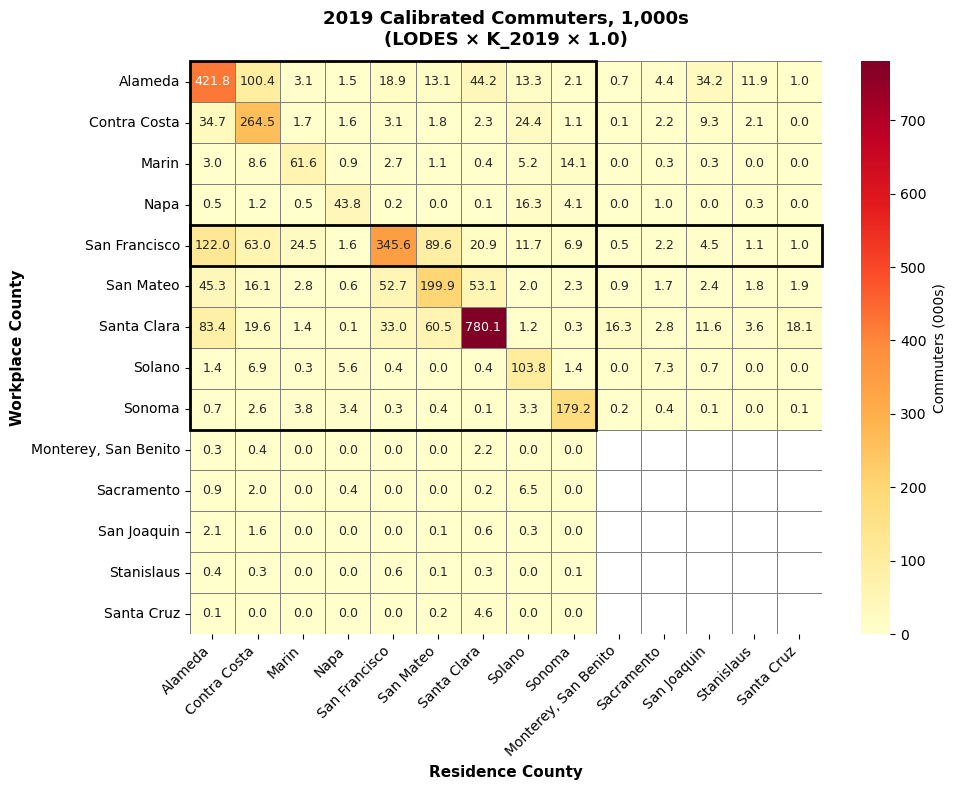

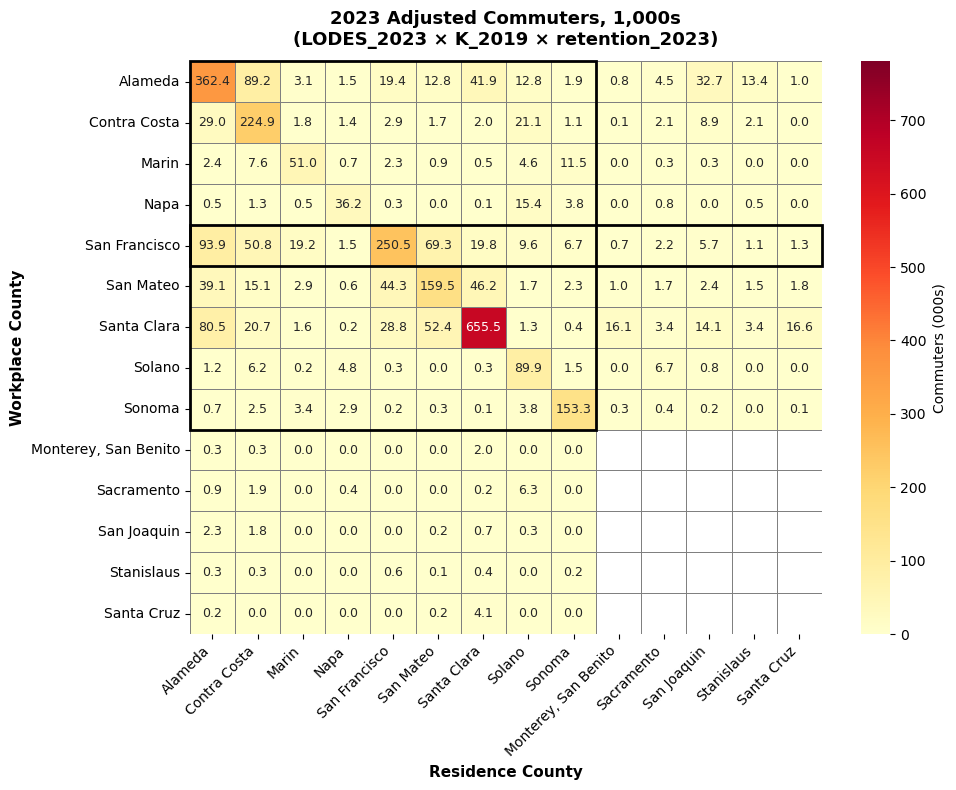

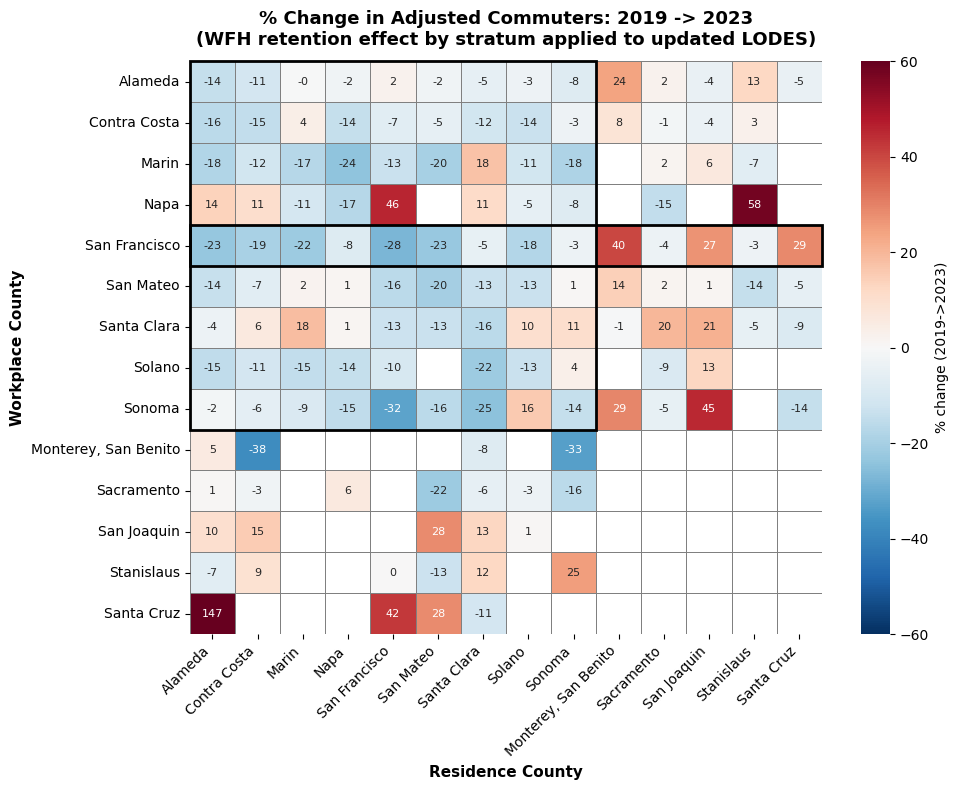

In [ ]:
# Step 5d: Heatmaps - 2019 Calibrated vs 2023 Adjusted 

vmax_cmp = max(calibrated_matrix.div(disp_scale).max().max(),
               adj_matrix_2023.div(disp_scale).max().max())

for mat, title in [
    (calibrated_matrix, f'2019 Calibrated Commuters, 1,000s\n(LODES × K_2019 × 1.0)'),
    (adj_matrix_2023,   f'2023 Adjusted Commuters, 1,000s\n(LODES_2023 × K_2019 x retention_2023)'),
]:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        mat.div(disp_scale).T,
        annot=True, fmt='.1f', cmap='YlOrRd',
        vmin=0, vmax=vmax_cmp,
        cbar_kws={'label': 'Commuters (000s)'},
        ax=ax, linewidths=0.5, linecolor='gray', annot_kws={'size': 9}
    )
    _highlight_heatmap(ax, county_combo_list)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Workplace County', fontsize=11, fontweight='bold')
    ax.set_xlabel('Residence County', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ── Δ heatmap: (2023 adj - 2019 cal) / 2019 cal, as % ────────────────────────
# Clip denominator to avoid ÷0; mask cells where both are near 0
with np.errstate(divide='ignore', invalid='ignore'):
    pct_change = ((adj_matrix_2023.T - calibrated_matrix.T) /
                   calibrated_matrix.T.replace(0, np.nan) * 100)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pct_change,
    annot=True, fmt='.0f', cmap='RdBu_r',
    center=0, vmin=-60, vmax=60,
    cbar_kws={'label': '% change (2019->2023)'},
    ax=ax, linewidths=0.5, linecolor='gray', annot_kws={'size': 8}
)
_highlight_heatmap(ax, county_combo_list)
ax.set_title(
    f'% Change in Adjusted Commuters: 2019 -> 2023\n'
    f'(WFH retention effect by stratum applied to updated LODES)',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_ylabel('Workplace County', fontsize=11, fontweight='bold')
ax.set_xlabel('Residence County', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Reading the Three Heatmaps

#### What each chart represents

| Chart | Formula | Description |
|---|---|---|
| **2019 Calibrated** | LODES₂₀₁₉ × K₂₀₁₉ | Baseline: 2019 raw LODES jobs scaled by the PUMS-derived behavioral ratio |
| **2023 Adjusted** | LODES₂₀₂₃ × K₂₀₁₉ × retention₂₀₂₃ | Out-of-sample estimate: 2023 LODES jobs with the 2019 K-factor damped by WFH growth |
| **% Change map** | (2023 adj − 2019 cal) / 2019 cal | Net effect of both forces combined - positive cells grew, negative cells shrank |

The third chart (difference map, `pct_change`) is what `adj_matrix_2023` represents relative to `calibrated_matrix` - it is **not** a direct read of either individual heatmap, but intstead the ratio of the two.



#### What drives the cell-by-cell changes

The % change in any OD cell is the product of two independent forces:

1. **LODES volume change (2019->2023)**: Raw administrative job counts may be higher or lower in 2023 due to actual employment change, firm restructuring, or growth in remote-hire relationships recorded at the employer address regardless of where the worker sits.

2. **WFH mobility retention (stratum-specific)**: The `k_adj_factor` scales down the K for strata that shifted toward remote work. This is derived from the change in the JWTR=11 share between 2019 and 2023 PUMS for Bay Area workers in each age x wage x industry cell. High-wage services workers (SI03 × SE03) show the largest reduction; goods-producing and low-wage workers (SI01 x SE01) show almost none.

These two forces can reinforce or offset each other:
- An OD cell where LODES grew **and** WFH rose sharply could show a modest net change (or even a slight decline) if the retention factor outweighs the job growth.
- An OD cell where LODES contracted **and** high WFH growth applies will show the deepest red.

---

#### Why San Francisco shows the largest reduction

The within-SF diagonal (SF residents working in SF) is the single largest cell in the matrix that goes most negative, and this is expected — but with important qualifications about what is and is not driving it.

**What is baked into the San Francisco decline:**

- **Stratum composition effect**: San Francisco's workforce skews heavily toward the exact strata with the highest WFH uptake - high-income, services-sector workers in middle and upper age cohorts (SI03 x SE03 x SA02/SA03). These strata carry the lowest retention factors. The WFH correction alone would push SF inward relative to, say, a warehouse-heavy county like Solano.

- **LODES denominator changes**: If the 2023 LODES records fewer SF-located jobs than 2019 (due to office downsizing, firm departures, or reclassification), this compounds the retention downscale. The net result is a doubly smaller numerator.

- **Frozen spatial topology**: The K₂₀₁₉ captures the 2019 OD *pattern* - who commutes into SF from each origin. The 2023 adjustment only scales the *magnitude* of each 2019 OD cell; it does not add new cross-county pairs or redistribute workers who may have moved residences. SF's gravitational pull as a workplace is held constant from 2019.

**What is NOT captured and therefore either overstated or understated:**

- **"Phantom" halo growth is only partially corrected**: LODES records workers in Sacramento or the Central Valley as SF-bound commuters if the employer is headquartered in SF. The retention factor reduces the *rate* at which those administrative ties become modeled trips, but does not remove the underlying LODES jobs. If remote hiring has inflated the 2023 LODES denominator for halo-to-SF flows, the adjusted figure will still be upward-biased relative to actual trips.

- **No behavioral data anchors 2023 geography**: Because post-2020 PUMS encodes WFH respondents' POWPUMA as their home address, we cannot observe whether the *spatial allocation* of which SF jobs attract which origin counties has changed. The 2019 OD topology is frozen in place; only the total volume per OD cell is rescaled downward.

**Plain statement of what this analysis does and does not show**: The WFH-adjusted 2023 estimate is a defensible estimate of *how many fewer trips* each stratum generates compared to 2019, applied to updated administrative job counts. It correctly identifies that SF-destined jobs in high-wage services are the primary source of trip reduction. What it cannot tell us is *which* origin counties that reduced SF inflow comes from, whether those workers have physically moved, or whether the employer itself has relocated. The spatial pattern of the 2023 adjusted matrix is 2019 with the volume turned down - it is not a fresh observation of 2023 commute geography.


In [43]:
# Step 5e: Export 

# 1. Full ODxstratum adjusted file
adj_strata_out = OUT_PATH / f'lodes_{WFH_YEAR}_od_puma_powpuma_adjusted.csv'
lodes_2023_adj[
    ['res_puma', 'h_counties', 'w_powpuma', 'w_counties',
     'age_cat', 'wage_cat', 'indp_cat',
     'lodes_jobs', 'k_factor_used', 'adjusted_commuters']
].to_csv(adj_strata_out, index=False)
print(f"Exported 2023 adjusted OD strata to:\n  {adj_strata_out}")

# 2. County-level long-form comparison (2019 calibrated, 2023 LODES raw, 2023 adjusted)
od_keys = ['res_county', 'work_county']
flows_2023 = (
    lodes_county_2023
    .rename(columns={'lodes_jobs': 'LODES_2023', 'adjusted_commuters': 'Adjusted_2023'})
    .merge(
        calibrated_flows.assign(
            res_county=calibrated_flows['res_county'],
            work_county=calibrated_flows['work_county']
        ).rename(columns={'calibrated_commuters': 'Calibrated_2019'}),
        on=od_keys, how='outer'
    )
    .fillna(0)
    .melt(id_vars=od_keys, var_name='source', value_name='flows')
    .assign(year=lambda d: d['source'].str.extract(r'(\d{4})')[0].astype(int))
    .sort_values(od_keys + ['source'])
    .reset_index(drop=True)
)

county_cmp_out = OUT_PATH / f'county_od_flows_{WFH_YEAR}_vs_{YEAR}_long.csv'
flows_2023.to_csv(county_cmp_out, index=False)
print(f"Exported county-level comparison to:\n  {county_cmp_out}")


Exported 2023 adjusted OD strata to:
  M:\Projects\Worker Flows\pums_to_lodes_reconciliation\lodes_2023_od_puma_powpuma_adjusted.csv
Exported county-level comparison to:
  M:\Projects\Worker Flows\pums_to_lodes_reconciliation\county_od_flows_2023_vs_2019_long.csv
